<a href="https://colab.research.google.com/github/Aleksei185/football-odds-lstm/blob/main/notebooks/01_lstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Загрузка данных из SQLite


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np

db_path = '/content/drive/MyDrive/database.sqlite'
conn = sqlite3.connect(db_path)

print("\nЗагрузка таблицы Match (только Bet365)")
query_match = """
SELECT
    m.id AS match_id,
    m.date,
    m.season,
    m.stage,
    m.home_team_api_id,
    m.away_team_api_id,
    m.home_team_goal,
    m.away_team_goal,
    m.B365H, m.B365D, m.B365A
FROM Match m
WHERE m.date IS NOT NULL
"""
df_matches = pd.read_sql_query(query_match, conn)
print(f"Загружено {len(df_matches)} матчей")

print("\nЗагрузка таблицы Team...")
df_teams = pd.read_sql_query("SELECT team_api_id, team_long_name FROM Team", conn)
print(f"Загружено {len(df_teams)} команд")

# Загружаем таблицу Team_Attributes (БЕЗ buildUpPlayDribbling)
print("\nЗагрузка таблицы Team_Attributes...")
query_team_attr = """
SELECT
    team_api_id,
    date,
    buildUpPlaySpeed,
    buildUpPlayPassing,
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,
    defencePressure,
    defenceAggression,
    defenceTeamWidth
FROM Team_Attributes
"""
df_team_attr = pd.read_sql_query(query_team_attr, conn)
df_team_attr['date'] = pd.to_datetime(df_team_attr['date'])
print(f"Загружено {len(df_team_attr)} записей об атрибутах")

# Объединяем матчи с названиями команд
print("\nОбъединение с названиями команд")
df_matches['date'] = pd.to_datetime(df_matches['date'])

df_matches = df_matches.merge(
    df_teams, left_on='home_team_api_id', right_on='team_api_id', how='left'
).rename(columns={'team_long_name': 'home_team_name'}).drop('team_api_id', axis=1)

df_matches = df_matches.merge(
    df_teams, left_on='away_team_api_id', right_on='team_api_id', how='left'
).rename(columns={'team_long_name': 'away_team_name'}).drop('team_api_id', axis=1)
print("Названия команд добавлены")

# Объединение с атрибутами через merge_asof
print("\nОбъединение с атрибутами команд (оптимизированно)")

df_matches = df_matches.sort_values('date')
df_team_attr = df_team_attr.sort_values('date')

def merge_attributes_fast(matches, attributes, team_col, prefix):
    attrs = attributes.rename(columns={'team_api_id': team_col})
    matches_sorted = matches.sort_values('date')
    attrs_sorted = attrs.sort_values('date')

    merged = pd.merge_asof(
        matches_sorted,
        attrs_sorted,
        on='date',
        by=team_col,
        direction='nearest'
    )

    attr_cols = ['buildUpPlaySpeed', 'buildUpPlayPassing',
                 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting',
                 'defencePressure', 'defenceAggression', 'defenceTeamWidth']

    for col in attr_cols:
        merged.rename(columns={col: f'{prefix}_{col}'}, inplace=True)

    return merged

df_matches = merge_attributes_fast(df_matches, df_team_attr, 'home_team_api_id', 'home')
df_matches = merge_attributes_fast(df_matches, df_team_attr, 'away_team_api_id', 'away')

print("Атрибуты команд добавлены")

# 7. Удаляем строки с пропусками (ТОЛЬКО Bet365 + атрибуты)
print("\nУдаление строк с пропусками...")

# Список колонок, где не должно быть пропусков
cols_to_check = ['B365H', 'B365D', 'B365A'] + [col for col in df_matches.columns if col.startswith('home_') or col.startswith('away_')]

df_matches = df_matches.dropna(subset=cols_to_check)
print(f"Осталось {len(df_matches)} матчей после удаления пропусков")

# 8. Выводим итоговую информацию
print("\n" + "="*60)
print("ИТОГОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df_matches.shape[0]} строк, {df_matches.shape[1]} колонок")
print(f"\nСписок колонок ({len(df_matches.columns)}):")
print(df_matches.columns.tolist())
print(f"\nПервые 3 строки:")
display(df_matches.head(3))
print(f"\nПропуски в данных:")
print(df_matches.isnull().sum().sum(), "пропусков")

conn.close()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Загрузка таблицы Match (только Bet365)
Загружено 25979 матчей

Загрузка таблицы Team...
Загружено 299 команд

Загрузка таблицы Team_Attributes...
Загружено 1458 записей об атрибутах

Объединение с названиями команд
Названия команд добавлены

Объединение с атрибутами команд (оптимизированно)
Атрибуты команд добавлены

Удаление строк с пропусками...
Осталось 22309 матчей после удаления пропусков

ИТОГОВАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 22309 строк, 29 колонок

Список колонок (29):
['match_id', 'date', 'season', 'stage', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'B365H', 'B365D', 'B365A', 'home_team_name', 'away_team_name', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_d

,match_id,date,season,stage,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,B365H,B365D,...,home_defenceAggression,home_defenceTeamWidth,away_buildUpPlaySpeed,away_buildUpPlayPassing,away_chanceCreationPassing,away_chanceCreationCrossing,away_chanceCreationShooting,away_defencePressure,away_defenceAggression,away_defenceTeamWidth
22,4769,2008-08-09,2008/2009,1,8583,9830,2,1,2.10,3.1,...,55.0,30.0,55.0,35.0,60.0,65.0,35.0,30.0,45.0,30.0
23,19694,2008-08-09,2008/2009,1,8596,8548,0,1,6.50,4.0,...,70.0,70.0,65.0,50.0,70.0,70.0,70.0,60.0,70.0,70.0
24,4775,2008-08-09,2008/2009,1,8481,8639,0,0,2.15,3.1,...,70.0,70.0,70.0,60.0,50.0,45.0,55.0,55.0,70.0,55.0



Пропуски в данных:
0 пропусков


Анализ данных и их визуализация

df_matches уже в памяти. Продолжаем.
ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)

Проверка данных:
Размер: (22309, 29)
Типы данных (первые 10):
match_id                     int64
date                datetime64[ns]
season                      object
stage                        int64
home_team_api_id             int64
away_team_api_id             int64
home_team_goal               int64
away_team_goal               int64
B365H                      float64
B365D                      float64
dtype: object

Пропуски: 0

1. РАСПРЕДЕЛЕНИЕ ИСХОДОВ МАТЧЕЙ
Победа хозяев: 10239 (45.90%)
Ничья: 5647 (25.31%)
Победа гостей: 6423 (28.79%)


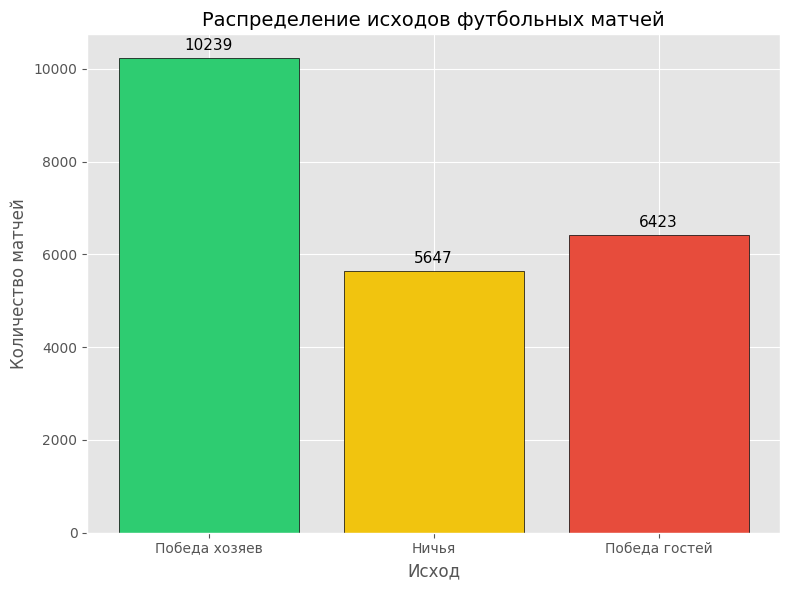


2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365


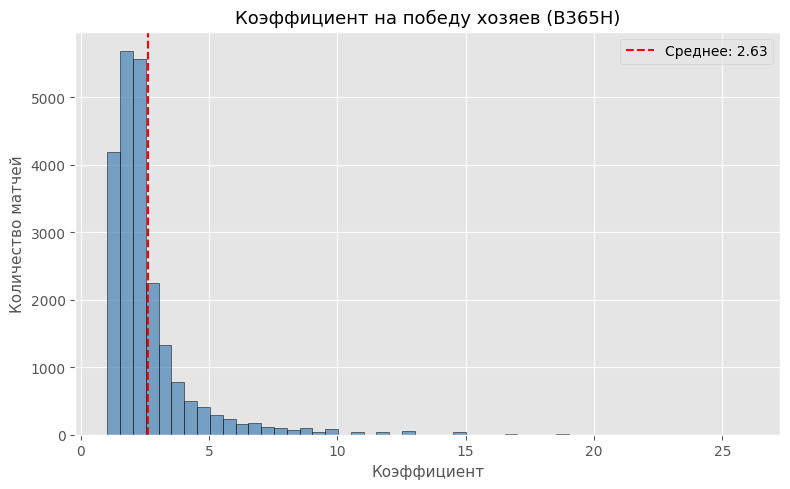

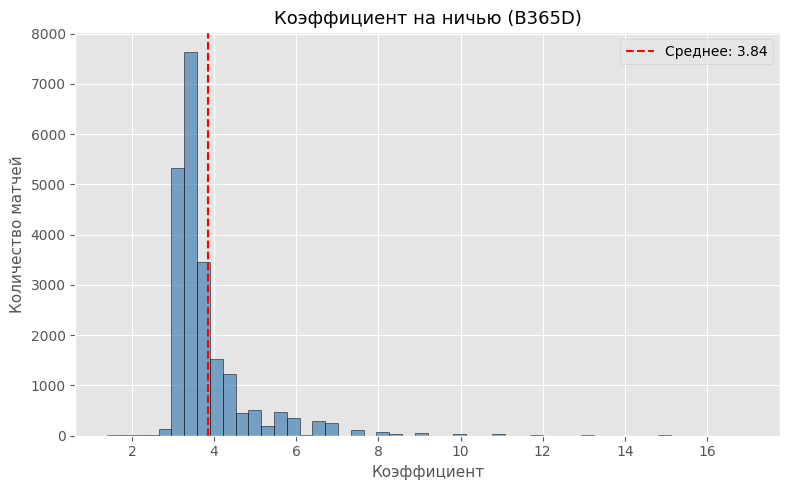

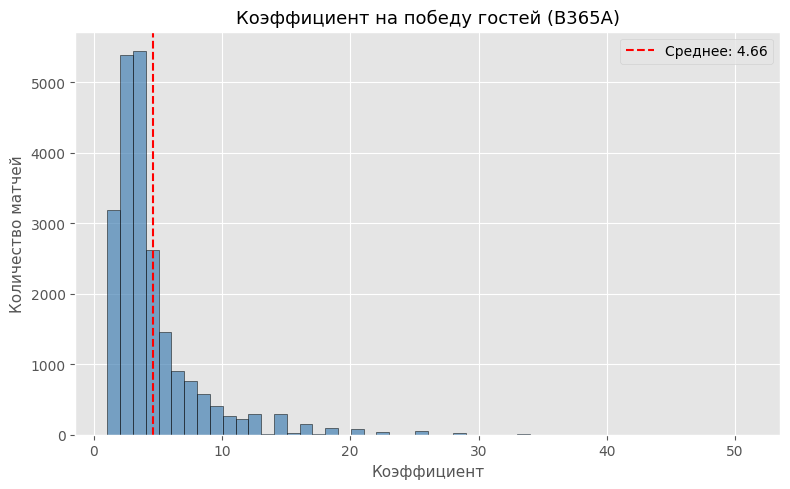


3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ


/tmp/ipykernel_3737/3554377949.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


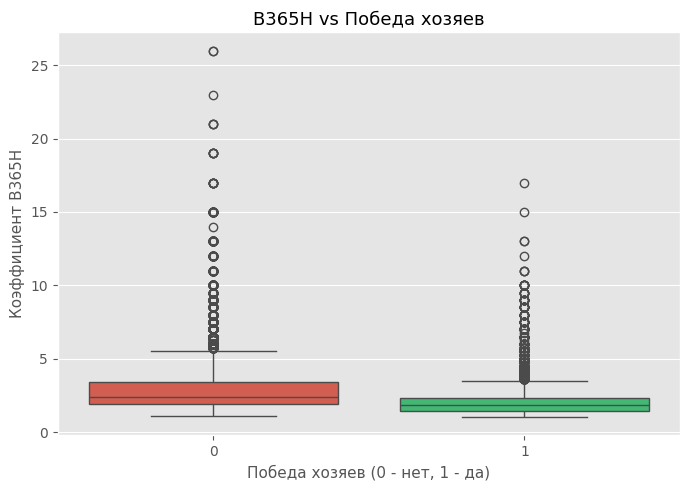

/tmp/ipykernel_3737/3554377949.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


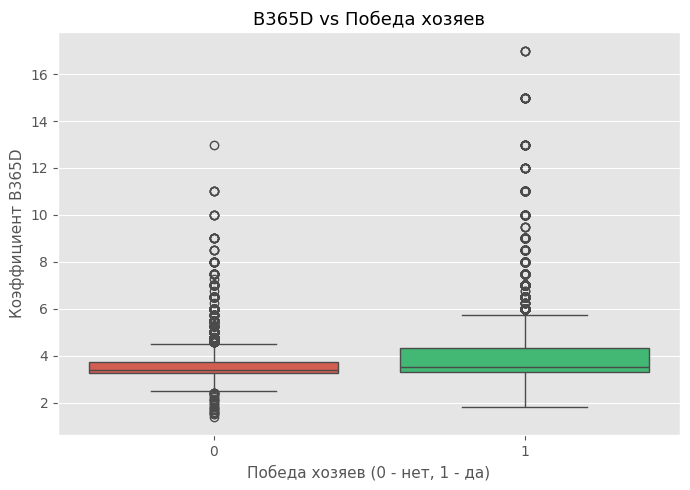

/tmp/ipykernel_3737/3554377949.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


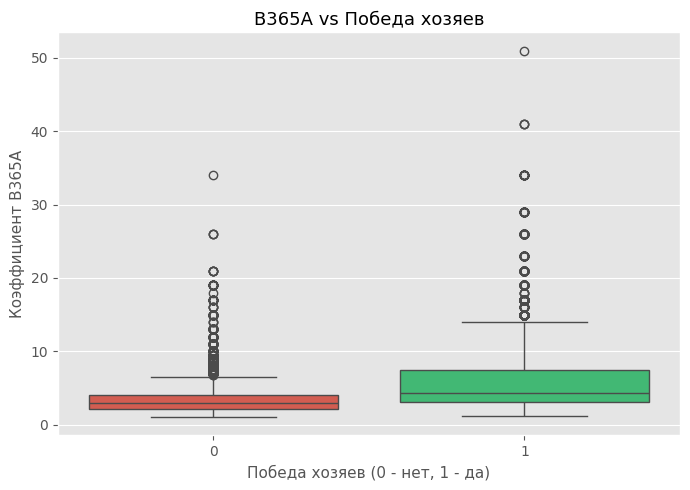


4. МАТРИЦА КОРРЕЛЯЦИЙ
Числовых колонок для корреляции: 24
Список: ['home_team_goal', 'away_team_goal', 'B365H', 'B365D', 'B365A', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_defenceTeamWidth', 'away_buildUpPlaySpeed', 'away_buildUpPlayPassing', 'away_chanceCreationPassing', 'away_chanceCreationCrossing', 'away_chanceCreationShooting', 'away_defencePressure', 'away_defenceAggression', 'away_defenceTeamWidth', 'home_win', 'draw', 'away_win']


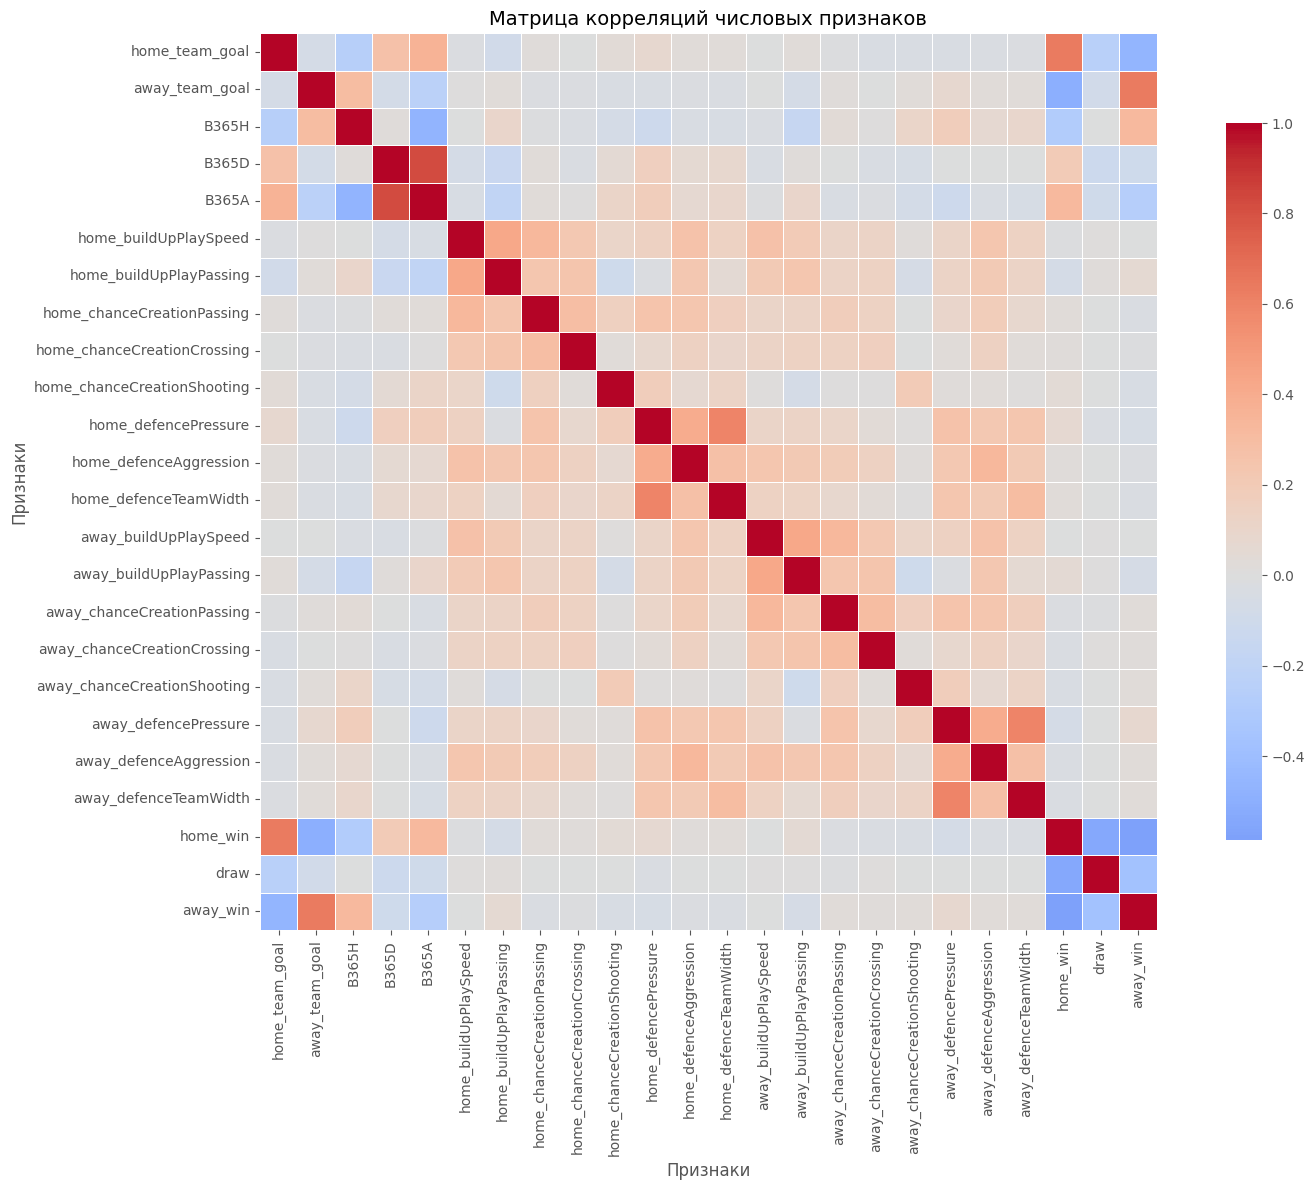


5. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С HOME_WIN
home_team_goal                 0.637115
B365A                          0.320101
B365D                          0.198419
home_defencePressure           0.069425
away_buildUpPlayPassing        0.046344
home_chanceCreationShooting    0.045060
home_defenceTeamWidth          0.023588
home_chanceCreationPassing     0.022699
home_defenceAggression         0.017165
home_chanceCreationCrossing    0.016283
away_buildUpPlaySpeed          0.000361
home_buildUpPlaySpeed         -0.010484
away_chanceCreationPassing    -0.019318
away_defenceAggression        -0.024951
away_chanceCreationCrossing   -0.025802
away_defenceTeamWidth         -0.026688
away_chanceCreationShooting   -0.028388
away_defencePressure          -0.064561
home_buildUpPlayPassing       -0.067649
B365H                         -0.283733
away_team_goal                -0.502107
draw                          -0.536192
away_win                      -0.585648


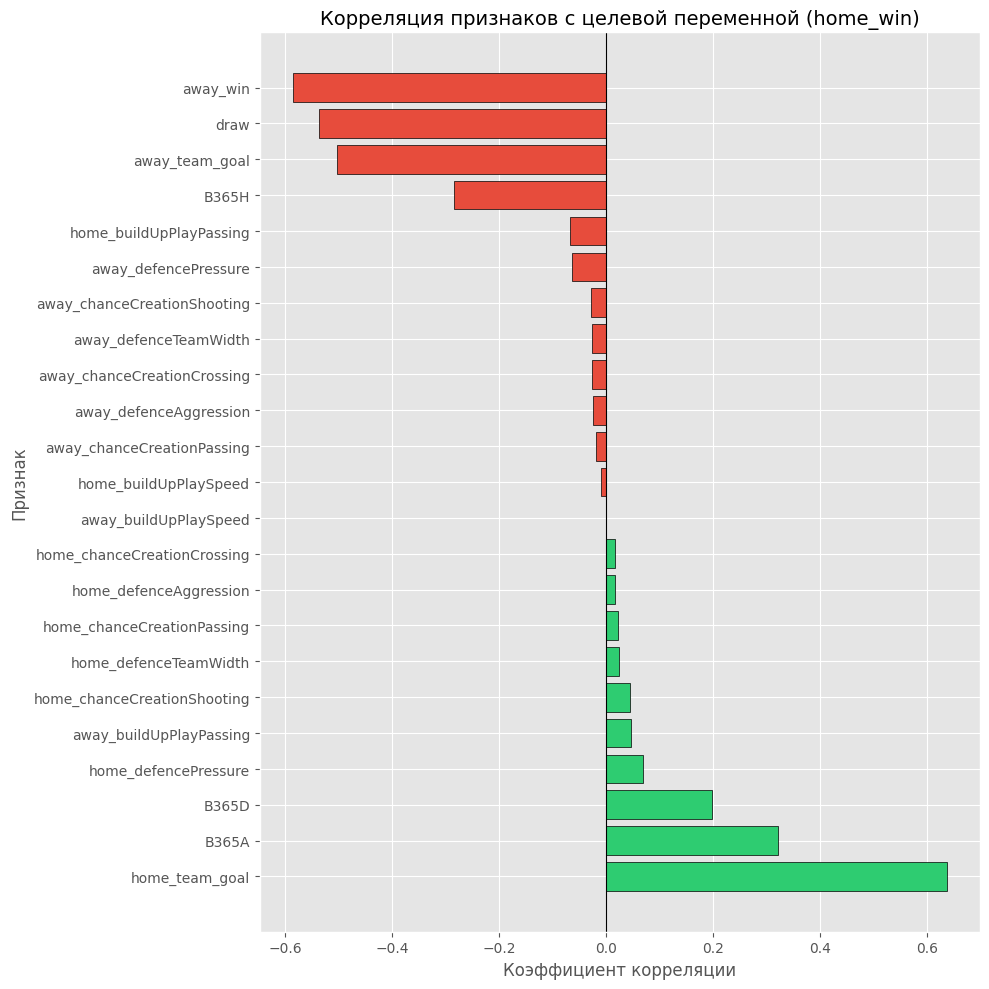


6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)
Атрибуты хозяев: ['home_team_api_id', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_defenceTeamWidth']


/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


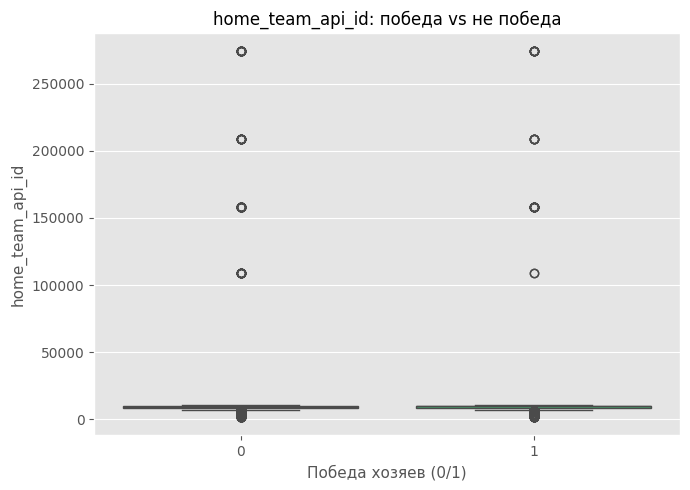

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


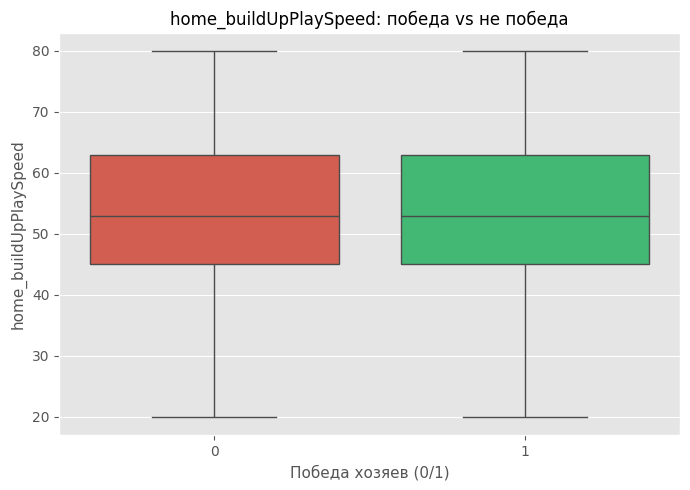

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


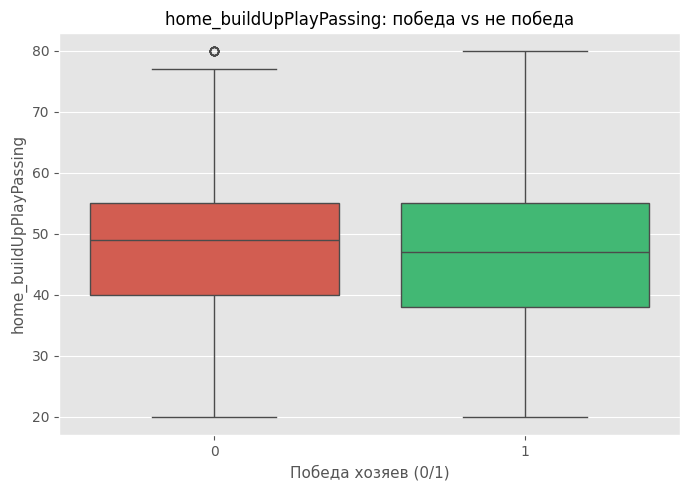

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


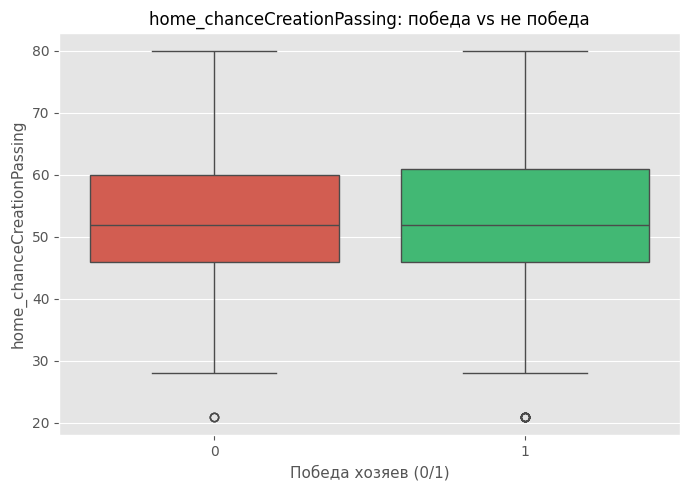

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


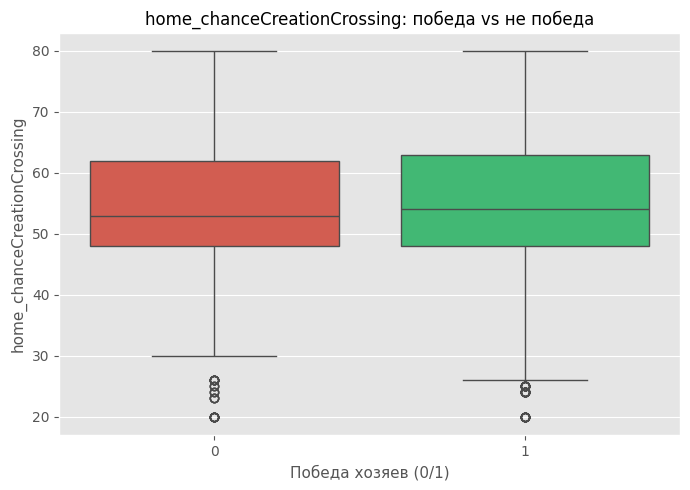

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


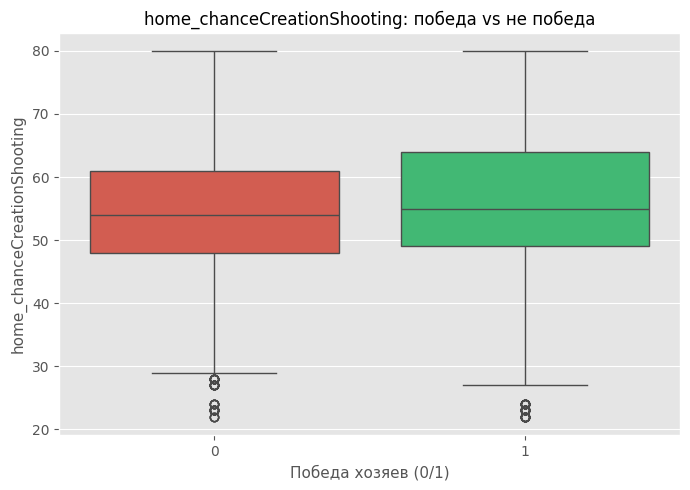

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


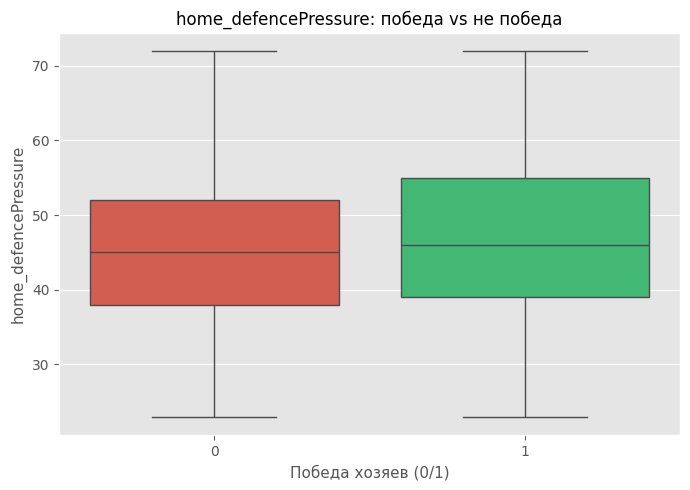

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


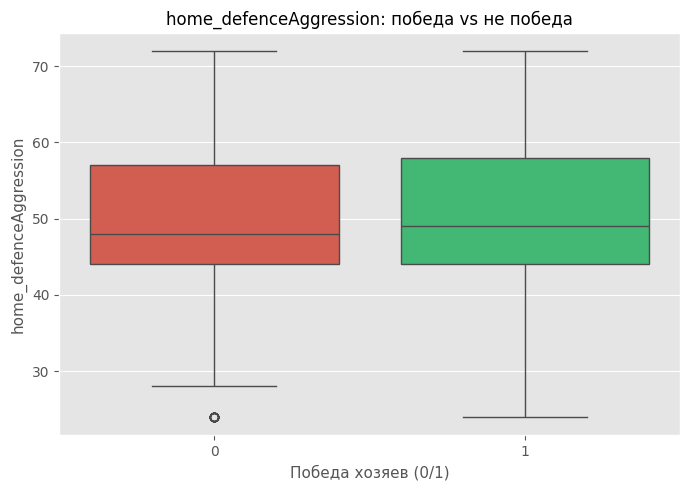

/tmp/ipykernel_3737/3554377949.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


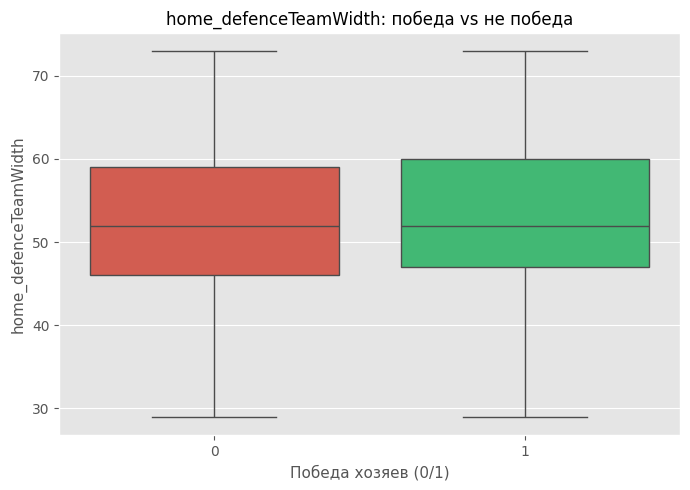


7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)
Атрибуты гостей: ['away_team_api_id', 'away_buildUpPlaySpeed', 'away_buildUpPlayPassing', 'away_chanceCreationPassing', 'away_chanceCreationCrossing', 'away_chanceCreationShooting', 'away_defencePressure', 'away_defenceAggression', 'away_defenceTeamWidth', 'away_win']


/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


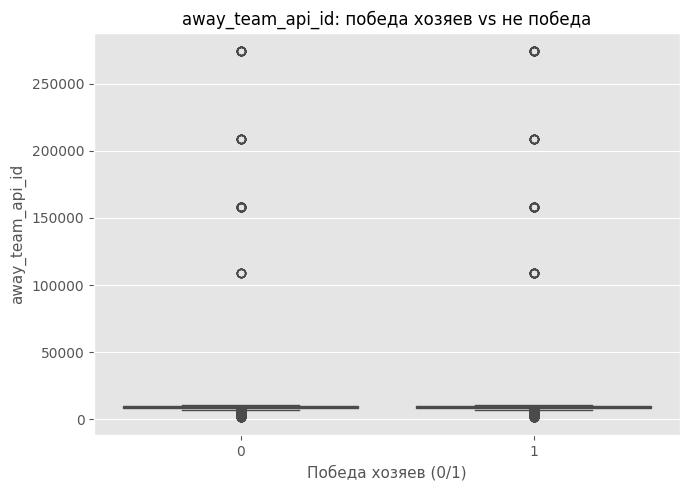

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


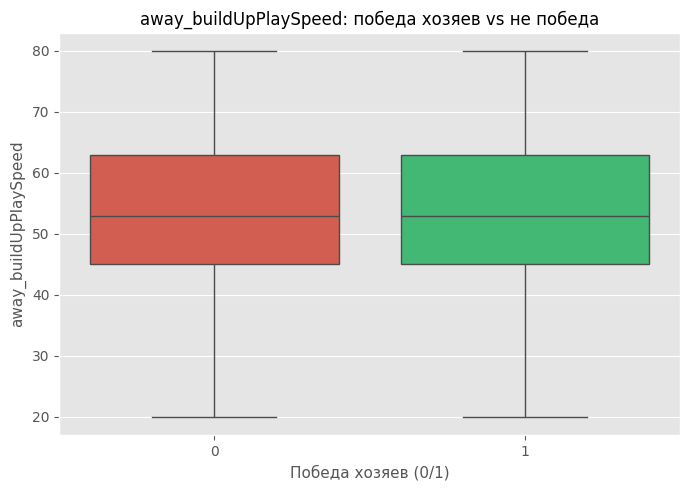

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


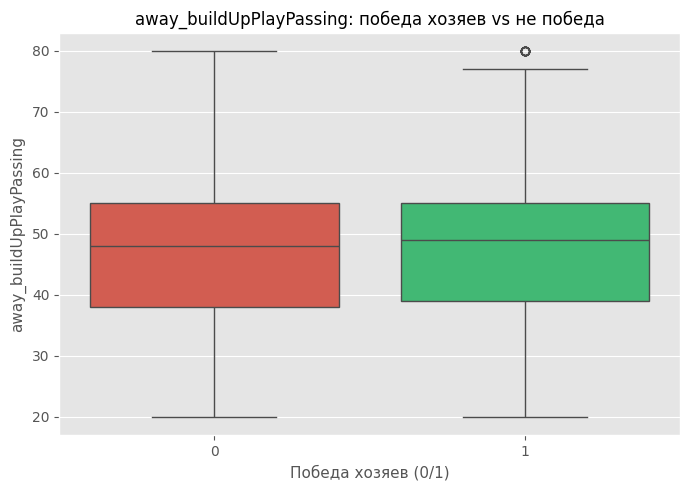

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


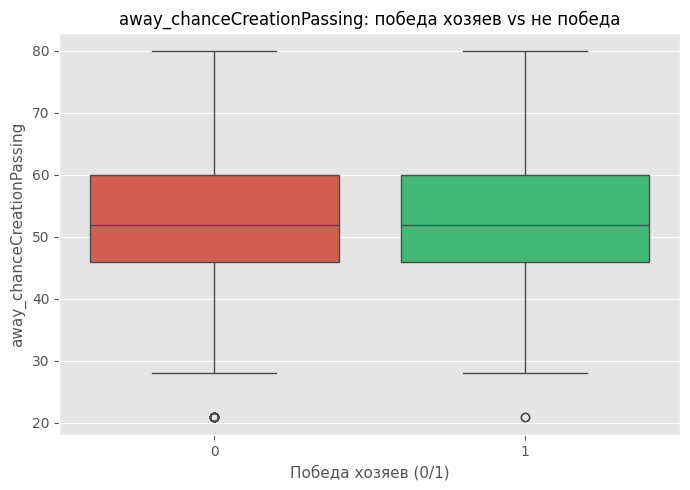

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


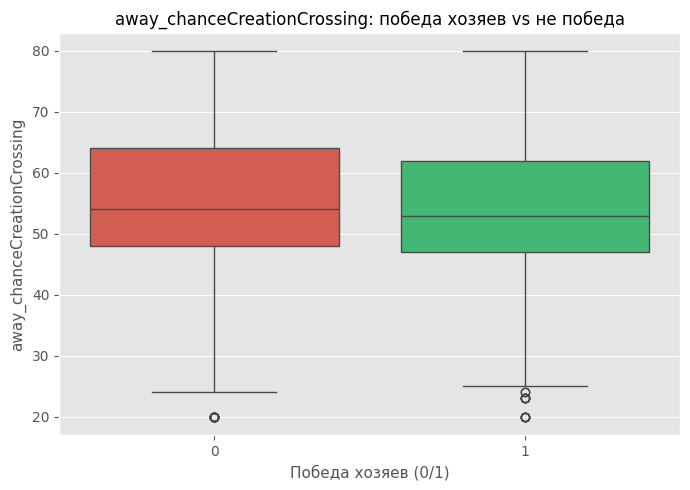

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


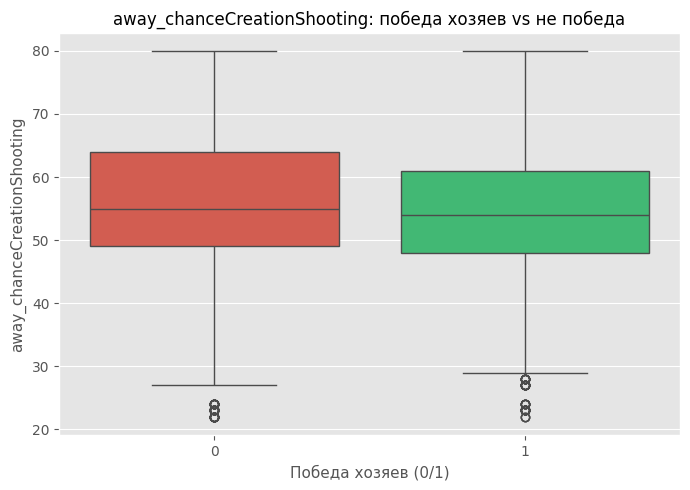

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


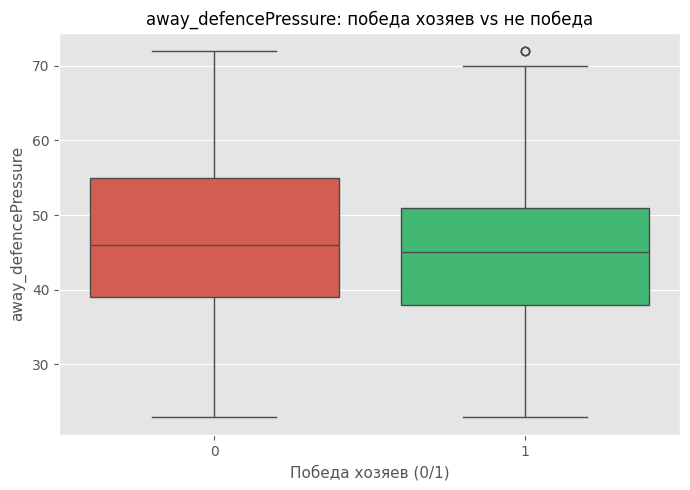

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


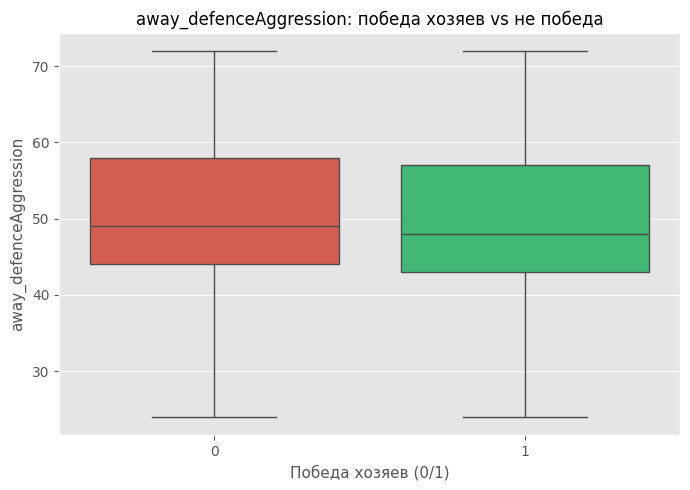

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


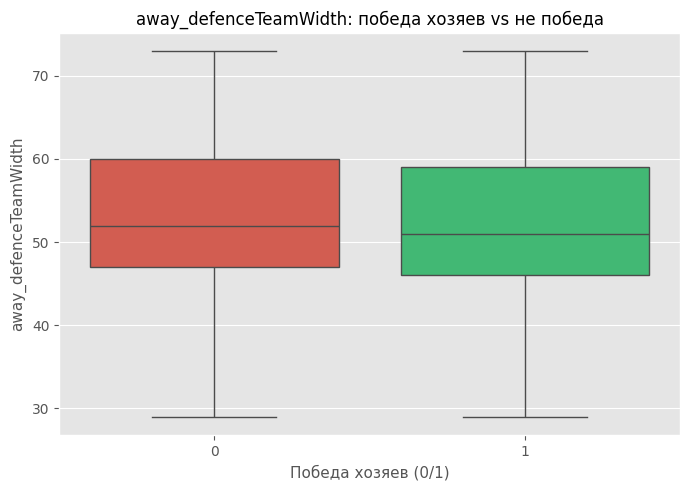

/tmp/ipykernel_3737/3554377949.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


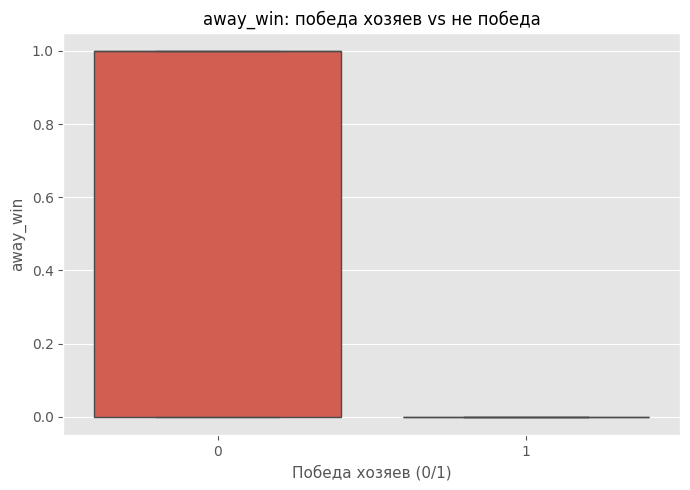


8. БАЛАНС КЛАССОВ (HOME_WIN)
Класс 0 (не победа хозяев): 12070 (54.10%)
Класс 1 (победа хозяев): 10239 (45.90%)


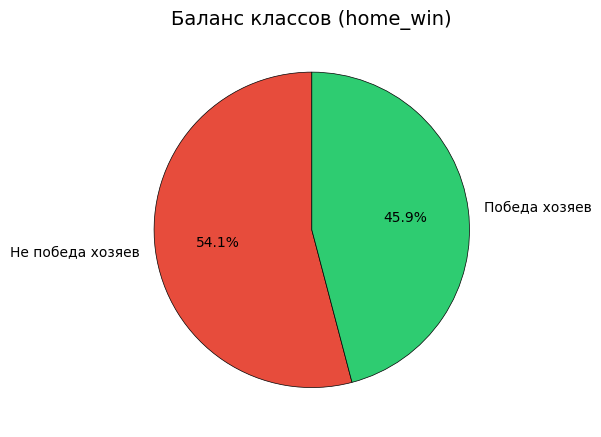

In [15]:
try:
    df_matches
    print("df_matches уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: df_matches не найдена. Выполните Этап 1 заново.")
    raise

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("="*60)
print("ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)")
print("="*60)

# ПРОВЕРКА ДАННЫХ
print("\nПроверка данных:")
print(f"Размер: {df_matches.shape}")
print(f"Типы данных (первые 10):")
print(df_matches.dtypes.head(10))
print(f"\nПропуски: {df_matches.isnull().sum().sum()}")

# 1. СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
df_matches['home_win'] = (df_matches['home_team_goal'] > df_matches['away_team_goal']).astype(int)
df_matches['draw'] = (df_matches['home_team_goal'] == df_matches['away_team_goal']).astype(int)
df_matches['away_win'] = (df_matches['home_team_goal'] < df_matches['away_team_goal']).astype(int)

print("\n" + "="*60)
print("1. РАСПРЕДЕЛЕНИЕ ИСХОДОВ МАТЧЕЙ")
print("="*60)

outcome_counts = df_matches[['home_win', 'draw', 'away_win']].sum()
print(f"Победа хозяев: {outcome_counts['home_win']} ({outcome_counts['home_win']/len(df_matches)*100:.2f}%)")
print(f"Ничья: {outcome_counts['draw']} ({outcome_counts['draw']/len(df_matches)*100:.2f}%)")
print(f"Победа гостей: {outcome_counts['away_win']} ({outcome_counts['away_win']/len(df_matches)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(['Победа хозяев', 'Ничья', 'Победа гостей'],
              outcome_counts.values, color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black')
ax.set_title('Распределение исходов футбольных матчей', fontsize=14)
ax.set_xlabel('Исход', fontsize=12)
ax.set_ylabel('Количество матчей', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height)}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# 2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365
print("\n" + "="*60)
print("2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365")
print("="*60)

for col, title in zip(['B365H', 'B365D', 'B365A'],
                      ['Коэффициент на победу хозяев (B365H)',
                       'Коэффициент на ничью (B365D)',
                       'Коэффициент на победу гостей (B365A)']):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_matches[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Коэффициент', fontsize=11)
    ax.set_ylabel('Количество матчей', fontsize=11)
    ax.axvline(df_matches[col].mean(), color='red', linestyle='--',
               label=f'Среднее: {df_matches[col].mean():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# 3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ
print("\n" + "="*60)
print("3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ")
print("="*60)

for col in ['B365H', 'B365D', 'B365A']:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col} vs Победа хозяев', fontsize=13)
    ax.set_xlabel('Победа хозяев (0 - нет, 1 - да)', fontsize=11)
    ax.set_ylabel(f'Коэффициент {col}', fontsize=11)
    plt.tight_layout()
    plt.show()

# 4. МАТРИЦА КОРРЕЛЯЦИЙ
print("\n" + "="*60)
print("4. МАТРИЦА КОРРЕЛЯЦИЙ")
print("="*60)

# Определяем числовые колонки автоматически
numeric_cols = df_matches.select_dtypes(include=[np.number]).columns.tolist()
# Убираем служебные
numeric_cols = [col for col in numeric_cols if col not in
                ('match_id', 'home_team_api_id', 'away_team_api_id', 'stage')]

print(f"Числовых колонок для корреляции: {len(numeric_cols)}")
print(f"Список: {numeric_cols}")

corr_matrix = df_matches[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Матрица корреляций числовых признаков', fontsize=14)
ax.set_xlabel('Признаки', fontsize=12)
ax.set_ylabel('Признаки', fontsize=12)
plt.tight_layout()
plt.show()

# 5. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
print("\n" + "="*60)
print("5. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С HOME_WIN")
print("="*60)

corr_with_target = df_matches[numeric_cols].corr()['home_win'].drop('home_win').sort_values(ascending=False)
print(corr_with_target.to_string())

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Корреляция признаков с целевой переменной (home_win)', fontsize=14)
ax.set_xlabel('Коэффициент корреляции', fontsize=12)
ax.set_ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

# 6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)
print("\n" + "="*60)
print("6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)")
print("="*60)

home_attr_cols = [col for col in df_matches.columns
                  if col.startswith('home_') and col not in ('home_team_name', 'home_win', 'home_team_goal')]
print(f"Атрибуты хозяев: {home_attr_cols}")

for col in home_attr_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col}: победа vs не победа', fontsize=12)
    ax.set_xlabel('Победа хозяев (0/1)', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# 7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)
print("\n" + "="*60)
print("7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)")
print("="*60)

away_attr_cols = [col for col in df_matches.columns
                  if col.startswith('away_') and col not in ('away_team_name', 'away_team_goal')]
print(f"Атрибуты гостей: {away_attr_cols}")

for col in away_attr_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col}: победа хозяев vs не победа', fontsize=12)
    ax.set_xlabel('Победа хозяев (0/1)', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# 8. БАЛАНС КЛАССОВ
print("\n" + "="*60)
print("8. БАЛАНС КЛАССОВ (HOME_WIN)")
print("="*60)

balance = df_matches['home_win'].value_counts()
print(f"Класс 0 (не победа хозяев): {balance[0]} ({balance[0]/len(df_matches)*100:.2f}%)")
print(f"Класс 1 (победа хозяев): {balance[1]} ({balance[1]/len(df_matches)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(balance.values, labels=['Не победа хозяев', 'Победа хозяев'],
       autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90,
       wedgeprops={'edgecolor': 'black'})
ax.set_title('Баланс классов (home_win)', fontsize=14)
plt.tight_layout()
plt.show()

Feature Engineering

In [16]:
# СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
print("\n" + "="*60)
print("СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ")
print("="*60)

# Implied probabilities (вероятности исходов)
df_matches['implied_prob_H'] = 1 / df_matches['B365H']
df_matches['implied_prob_D'] = 1 / df_matches['B365D']
df_matches['implied_prob_A'] = 1 / df_matches['B365A']
print("Созданы признаки: implied_prob_H, implied_prob_D, implied_prob_A")

# Odds ratios (соотношения коэффициентов)
df_matches['odds_ratio_HA'] = df_matches['B365H'] / df_matches['B365A']
df_matches['odds_ratio_HD'] = df_matches['B365H'] / df_matches['B365D']
df_matches['odds_ratio_AD'] = df_matches['B365A'] / df_matches['B365D']
print("Созданы признаки: odds_ratio_HA, odds_ratio_HD, odds_ratio_AD")

print("\n" + "="*60)
print("ФОРМИРОВАНИЕ ИТОГОВОГО ДАТАСЕТА")
print("="*60)

# Список признаков для модели
feature_cols = [
    'B365H', 'B365D', 'B365A',
    'implied_prob_H', 'implied_prob_D', 'implied_prob_A',
    'odds_ratio_HA', 'odds_ratio_HD', 'odds_ratio_AD'
]

# Целевая переменная
target_col = 'home_win'

df_final = df_matches[feature_cols + [target_col]].copy()

print(f"Итоговый датасет: {df_final.shape[0]} строк, {df_final.shape[1]} колонок")
print(f"\nПризнаки ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")
print(f"\nЦелевая переменная: {target_col}")

# ПРОВЕРКА ПРОПУСКОВ И ТИПОВ
print("\n" + "="*60)
print("ПРОВЕРКА ДАННЫХ")
print("="*60)

print(f"Пропуски: {df_final.isnull().sum().sum()}")
print(f"\nТипы данных:")
print(df_final.dtypes)

# БАЗОВАЯ СТАТИСТИКА
print("\n" + "="*60)
print("БАЗОВАЯ СТАТИСТИКА ПРИЗНАКОВ")
print("="*60)

print(df_final.describe().T.to_string())

# ВЫВОД ПЕРВЫХ СТРОК
print("\n" + "="*60)
print("ПЕРВЫЕ 5 СТРОК ИТОГОВОГО ДАТАСЕТА")
print("="*60)

print(df_final.head().to_string())

# Сохраняем итоговый датасет в переменную df_final

print("Итоговый датасет сохранен в переменную 'df_final'")
print(f"Размер: {df_final.shape}")
print(f"Признаки: {feature_cols}")
print(f"Целевая переменная: {target_col}")


СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
Созданы признаки: implied_prob_H, implied_prob_D, implied_prob_A
Созданы признаки: odds_ratio_HA, odds_ratio_HD, odds_ratio_AD

ФОРМИРОВАНИЕ ИТОГОВОГО ДАТАСЕТА
Итоговый датасет: 22309 строк, 10 колонок

Признаки (9):
  1. B365H
  2. B365D
  3. B365A
  4. implied_prob_H
  5. implied_prob_D
  6. implied_prob_A
  7. odds_ratio_HA
  8. odds_ratio_HD
  9. odds_ratio_AD

Целевая переменная: home_win

ПРОВЕРКА ДАННЫХ
Пропуски: 0

Типы данных:
B365H             float64
B365D             float64
B365A             float64
implied_prob_H    float64
implied_prob_D    float64
implied_prob_A    float64
odds_ratio_HA     float64
odds_ratio_HD     float64
odds_ratio_AD     float64
home_win            int64
dtype: object

БАЗОВАЯ СТАТИСТИКА ПРИЗНАКОВ
                  count      mean       std       min       25%       50%       75%        max
B365H           22309.0  2.626414  1.786781  1.040000  1.670000  2.100000  2.800000  26.000000
B365D           22309.0  3.839853 

Подготовка данных для PyTorch

In [17]:
try:
    df_final
    print("df_final уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: df_final не найдена. Выполните Этап 3 заново.")
    raise

import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# РАЗДЕЛЕНИЕ НА ПРИЗНАКИ И ЦЕЛЕВУЮ ПЕРЕМЕННУЮ

feature_cols = [
    'B365H', 'B365D', 'B365A',
    'implied_prob_H', 'implied_prob_D', 'implied_prob_A',
    'odds_ratio_HA', 'odds_ratio_HD', 'odds_ratio_AD'
]
target_col = 'home_win'

X = df_final[feature_cols].values
y = df_final[target_col].values

# РАЗДЕЛЕНИЕ НА TRAIN / VAL / TEST (70/15/15)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# Проверка баланса классов
print(f"\nБаланс классов:")
print(f"Train: home_win=1: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Val:   home_win=1: {y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"Test:  home_win=1: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

# МАСШТАБИРОВАНИЕ ПРИЗНАКОВ

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nСредние значения признаков на train (после масштабирования): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Стандартные отклонения (после масштабирования): {X_train_scaled.std(axis=0).round(4)}")

# Преобразование в тензоры

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# СОЗДАНИЕ TENSORDATASET

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(f"\ntrain_dataset: {len(train_dataset)} примеров")
print(f"val_dataset:   {len(val_dataset)} примеров")
print(f"test_dataset:  {len(test_dataset)} примеров")

# Проверка: один пример из train_dataset
sample_X, sample_y = train_dataset[0]
print(f"\nПример из train_dataset:")
print(f"  X[0] (9 признаков): {sample_X.numpy().round(4)}")
print(f"  y[0] (целевая): {sample_y.item()}")

# СОЗДАНИЕ DATALOADER

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size: {BATCH_SIZE}")
print(f"Количество батчей в train_loader: {len(train_loader)}")
print(f"Количество батчей в val_loader:   {len(val_loader)}")
print(f"Количество батчей в test_loader:  {len(test_loader)}")

df_final уже в памяти. Продолжаем.

Баланс классов:
Train: home_win=1: 7171 (45.90%)
Val:   home_win=1: 1532 (45.90%)
Test:  home_win=1: 1536 (45.89%)

Средние значения признаков на train (после масштабирования): [-0. -0. -0.  0. -0.  0.  0.  0.  0.]
Стандартные отклонения (после масштабирования): [1. 1. 1. 1. 1. 1. 1. 1. 1.]

train_dataset: 15624 примеров
val_dataset:   3338 примеров
test_dataset:  3347 примеров

Пример из train_dataset:
  X[0] (9 признаков): [ 2.4519  0.4464 -0.8597 -1.8144 -0.8706  2.3331  2.4657  2.2914 -1.5366]
  y[0] (целевая): 1.0
Batch size: 64
Количество батчей в train_loader: 245
Количество батчей в val_loader:   53
Количество батчей в test_loader:  53


Обучение модели

DataLoader'ы уже в памяти. Продолжаем.
Используемое устройство: cpu
Папка проекта: /content/drive/MyDrive/football_ml_project

Всего параметров в модели: 9985

ОБУЧЕНИЕ С LEARNING RATE = 0.0001
  Эпоха   1: train_loss=0.6377, train_acc=0.6241, val_loss=0.6153, val_acc=0.6354
  Эпоха   5: train_loss=0.6241, train_acc=0.6500, val_loss=0.6165, val_acc=0.6369
  Эпоха  10: train_loss=0.6213, train_acc=0.6519, val_loss=0.6168, val_acc=0.6369
  Early stopping на эпохе 11

  Итог для lr=0.0001:
    Лучший val_loss: 0.6153
    Лучшая val_acc:  0.6354
    Лучшая эпоха:    1
    Остановка:       эпоха 11
    Время обучения:  10.0 сек

ОБУЧЕНИЕ С LEARNING RATE = 0.001
  Эпоха   1: train_loss=0.6251, train_acc=0.6484, val_loss=0.6169, val_acc=0.6405
  Эпоха   5: train_loss=0.6210, train_acc=0.6499, val_loss=0.6163, val_acc=0.6381
  Эпоха  10: train_loss=0.6197, train_acc=0.6532, val_loss=0.6175, val_acc=0.6360
  Эпоха  15: train_loss=0.6188, train_acc=0.6514, val_loss=0.6163, val_acc=0.6372
  Early

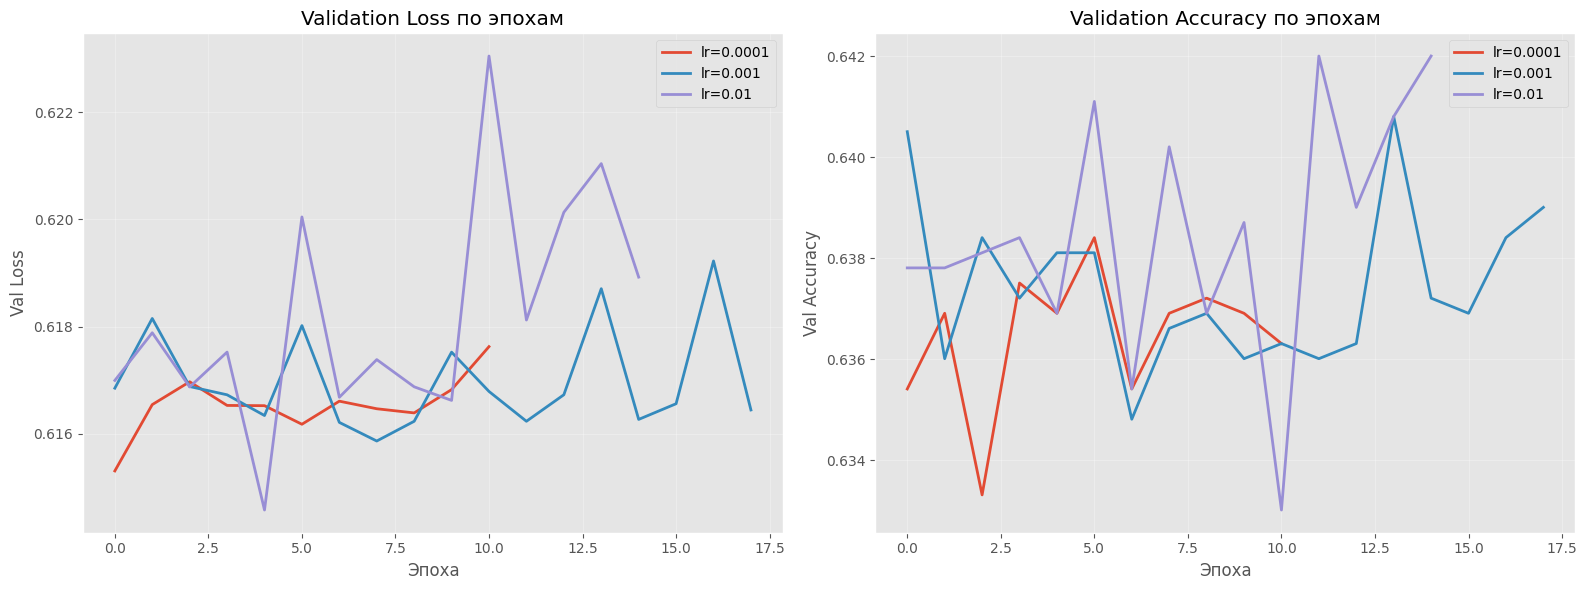


График сравнения сохранен: /content/drive/MyDrive/football_ml_project/plots/lr_comparison.png


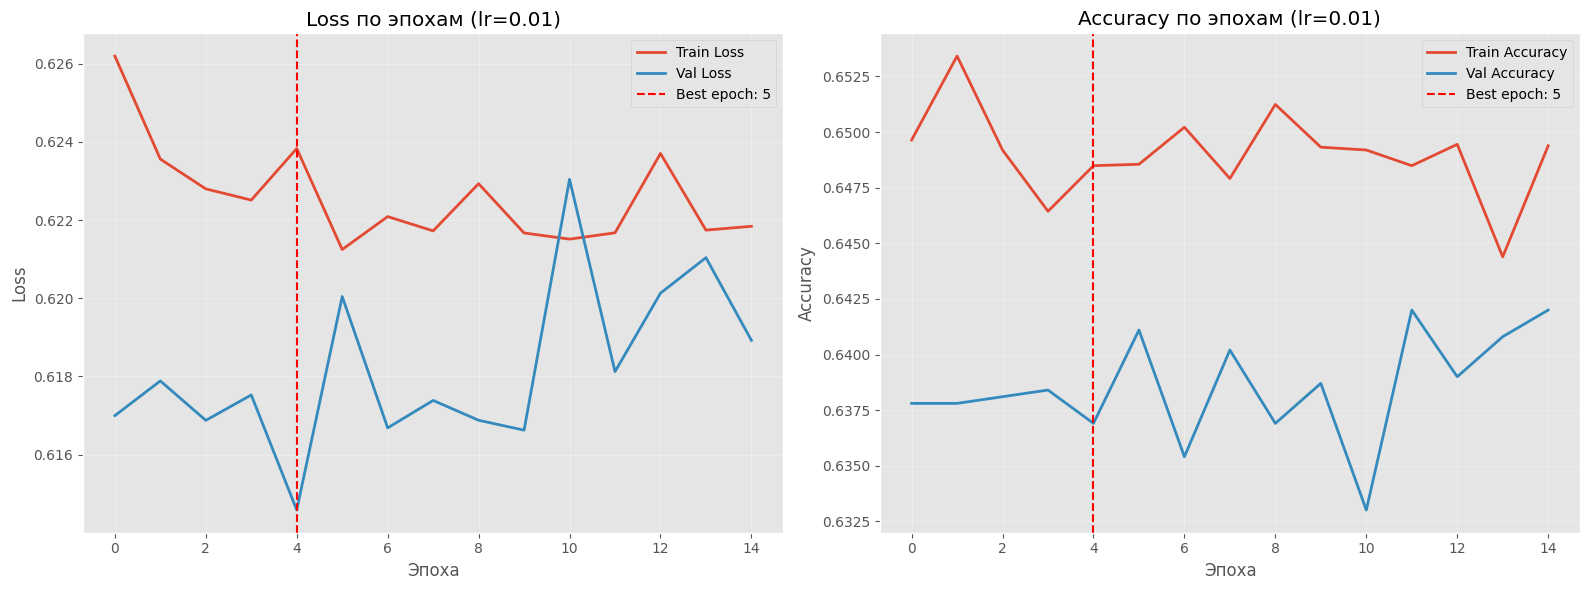

Графики loss и accuracy сохранены: /content/drive/MyDrive/football_ml_project/plots/loss_accuracy_curves.png

Лучшая модель сохранена: /content/drive/MyDrive/football_ml_project/best_model.pth
Результаты сохранены: /content/drive/MyDrive/football_ml_project/lr_comparison.json

ИТОГИ ОБУЧЕНИЯ
Проверено learning rate: [0.0001, 0.001, 0.01]
Лучший lr: 0.01
  Лучший val_loss: 0.6146
  Лучшая val_acc:  0.6369
  Лучшая эпоха:    5

Сохраненные файлы:
  - /content/drive/MyDrive/football_ml_project/best_model.pth
  - /content/drive/MyDrive/football_ml_project/lr_comparison.json
  - /content/drive/MyDrive/football_ml_project/plots/lr_comparison.png
  - /content/drive/MyDrive/football_ml_project/plots/loss_accuracy_curves.png


In [18]:
try:
    train_loader, val_loader, test_loader
    print("DataLoader'ы уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: DataLoader'ы не найдены. Выполните Этап 4 заново.")
    raise

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import json


# Настройка
plt.style.use('ggplot')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создаем папку проекта на Google Диске
PROJECT_PATH = '/content/drive/MyDrive/football_ml_project'
PLOTS_PATH = f'{PROJECT_PATH}/plots'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)
print(f"Папка проекта: {PROJECT_PATH}")


# ОПРЕДЕЛЕНИЕ КЛАССА МОДЕЛИ


class FootballMLP(nn.Module):
    def __init__(self, input_size=9, dropout=0.3):
        super(FootballMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.sigmoid(self.fc3(x))
        return x

# Проверка архитектуры
model_test = FootballMLP()
total_params = sum(p.numel() for p in model_test.parameters())
print(f"\nВсего параметров в модели: {total_params}")

# ФУНКЦИЯ ОБУЧЕНИЯ С EARLY STOPPING

def train_model(model, train_loader, val_loader, lr, max_epochs=100, patience=10):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        # TRAIN
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            train_correct += ((y_pred > 0.5).float() == y_batch).sum().item()
            train_total += len(y_batch)
        train_loss /= train_total
        train_acc = train_correct / train_total

        # VALIDATION
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch).squeeze()
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += ((y_pred > 0.5).float() == y_batch).sum().item()
                val_total += len(y_batch)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Эпоха {epoch+1:3d}: train_loss={train_loss:.4f}, "
                  f"train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if patience_counter >= patience:
            print(f"  Early stopping на эпохе {epoch+1}")
            break

    return history, best_val_loss, best_val_acc, best_epoch, epoch + 1, best_model_state

# ОБУЧЕНИЕ С РАЗНЫМИ LEARNING RATE


learning_rates = [0.0001, 0.001, 0.01]
results = {}

for lr in learning_rates:
    print(f"\nОБУЧЕНИЕ С LEARNING RATE = {lr}")

    torch.manual_seed(42)
    model = FootballMLP(input_size=9, dropout=0.3).to(device)

    start_time = time.time()
    history, best_val_loss, best_val_acc, best_epoch, stopped_epoch, best_state = train_model(
        model, train_loader, val_loader, lr=lr, max_epochs=100, patience=10
    )
    elapsed = time.time() - start_time

    results[lr] = {
        'history': history,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped_epoch,
        'best_model_state': best_state,
        'time': elapsed
    }

    print(f"\n  Итог для lr={lr}:")
    print(f"    Лучший val_loss: {best_val_loss:.4f}")
    print(f"    Лучшая val_acc:  {best_val_acc:.4f}")
    print(f"    Лучшая эпоха:    {best_epoch}")
    print(f"    Остановка:       эпоха {stopped_epoch}")
    print(f"    Время обучения:  {elapsed:.1f} сек")

# СРАВНЕНИЕ РЕЗУЛЬТАТОВ


print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ")

print(f"\n{'LR':>10} | {'Best Val Loss':>14} | {'Best Val Acc':>13} | {'Best Epoch':>11} | {'Stopped':>8} | {'Time (s)':>9}")
print("-" * 80)

for lr in learning_rates:
    r = results[lr]
    print(f"{lr:>10.4f} | {r['best_val_loss']:>14.4f} | {r['best_val_acc']:>13.4f} | "
          f"{r['best_epoch']:>11d} | {r['stopped_epoch']:>8d} | {r['time']:>9.1f}")

best_lr = min(learning_rates, key=lambda lr: results[lr]['best_val_loss'])
print(f"\nЛучший learning rate по val_loss: {best_lr}")
print(f"  val_loss: {results[best_lr]['best_val_loss']:.4f}")
print(f"  val_acc:  {results[best_lr]['best_val_acc']:.4f}")

# ГРАФИК СРАВНЕНИЯ LEARNING RATE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr in learning_rates:
    axes[0].plot(results[lr]['history']['val_loss'], label=f'lr={lr}', linewidth=2)
axes[0].set_title('Validation Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for lr in learning_rates:
    axes[1].plot(results[lr]['history']['val_acc'], label=f'lr={lr}', linewidth=2)
axes[1].set_title('Validation Accuracy по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Val Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nГрафик сравнения сохранен: {PLOTS_PATH}/lr_comparison.png")

# ГРАФИКИ ДЛЯ ЛУЧШЕЙ МОДЕЛИ

best_history = results[best_lr]['history']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(best_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(best_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(results[best_lr]['best_epoch'] - 1, color='red', linestyle='--',
                label=f"Best epoch: {results[best_lr]['best_epoch']}")
axes[0].set_title(f'Loss по эпохам (lr={best_lr})')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(best_history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].axvline(results[best_lr]['best_epoch'] - 1, color='red', linestyle='--',
                label=f"Best epoch: {results[best_lr]['best_epoch']}")
axes[1].set_title(f'Accuracy по эпохам (lr={best_lr})')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Графики loss и accuracy сохранены: {PLOTS_PATH}/loss_accuracy_curves.png")

# Сохранение на гугл диск

best_model = FootballMLP(input_size=9, dropout=0.3).to(device)
best_model.load_state_dict(results[best_lr]['best_model_state'])

model_path = f'{PROJECT_PATH}/best_model.pth'
torch.save(best_model.state_dict(), model_path)
print(f"\nЛучшая модель сохранена: {model_path}")

lr_results = {}
for lr in learning_rates:
    lr_results[str(lr)] = {
        'best_val_loss': float(results[lr]['best_val_loss']),
        'best_val_acc': float(results[lr]['best_val_acc']),
        'best_epoch': int(results[lr]['best_epoch']),
        'stopped_epoch': int(results[lr]['stopped_epoch']),
        'time_seconds': float(results[lr]['time'])
    }
lr_results['best_lr'] = str(best_lr)

with open(f'{PROJECT_PATH}/lr_comparison.json', 'w') as f:
    json.dump(lr_results, f, indent=4)
print(f"Результаты сохранены: {PROJECT_PATH}/lr_comparison.json")

# Итоги обучения

print("\n" + "="*60)
print("ИТОГИ ОБУЧЕНИЯ")
print("="*60)
print(f"Проверено learning rate: {learning_rates}")
print(f"Лучший lr: {best_lr}")
print(f"  Лучший val_loss: {results[best_lr]['best_val_loss']:.4f}")
print(f"  Лучшая val_acc:  {results[best_lr]['best_val_acc']:.4f}")
print(f"  Лучшая эпоха:    {results[best_lr]['best_epoch']}")
print(f"\nСохраненные файлы:")
print(f"  - {PROJECT_PATH}/best_model.pth")
print(f"  - {PROJECT_PATH}/lr_comparison.json")
print(f"  - {PLOTS_PATH}/lr_comparison.png")
print(f"  - {PLOTS_PATH}/loss_accuracy_curves.png")

ОЦЕНКА 2-СЛОЙНОЙ МОДЕЛИ НА TEST

DataLoader'ы и данные уже в памяти. Продолжаем.
Модель загружена: /content/drive/MyDrive/football_ml_project/best_model.pth
Предсказания получены: 3347 матчей
Средняя вероятность: 0.4585

МЕТРИКИ НА TEST
Accuracy:  0.6627
Precision: 0.6584
Recall:    0.5508
F1-score:  0.5998
ROC-AUC:   0.7142

Classification Report:
              precision    recall  f1-score   support

   Не победа       0.67      0.76      0.71      1811
      Победа       0.66      0.55      0.60      1536

    accuracy                           0.66      3347
   macro avg       0.66      0.65      0.65      3347
weighted avg       0.66      0.66      0.66      3347


Матрица ошибок:
[[1372  439]
 [ 690  846]]


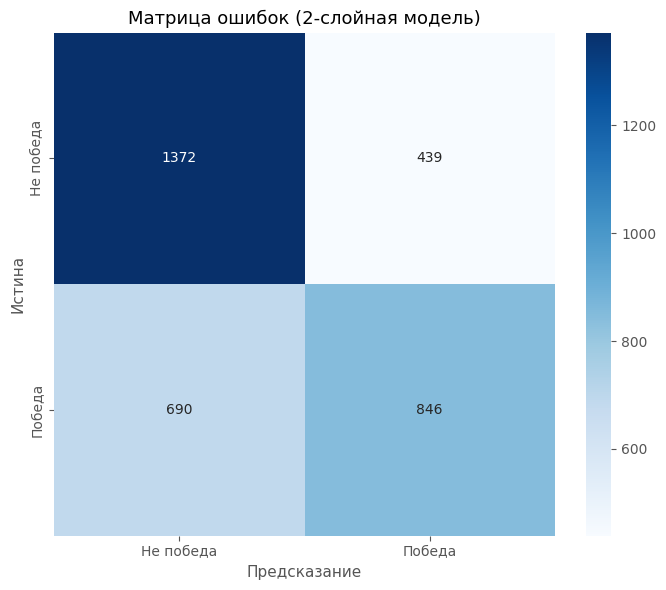

Сохранено: /content/drive/MyDrive/football_ml_project/plots/confusion_matrix_2layer.png


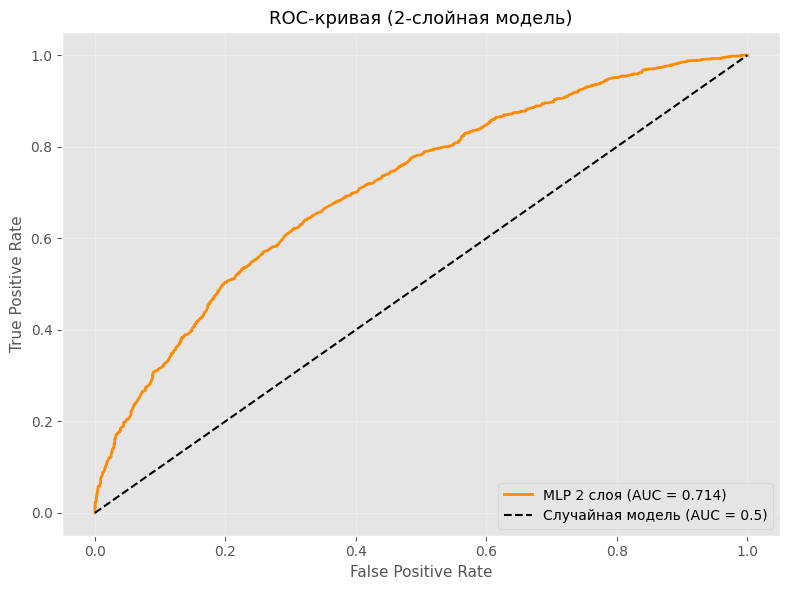

Сохранено: /content/drive/MyDrive/football_ml_project/plots/roc_curve_2layer.png


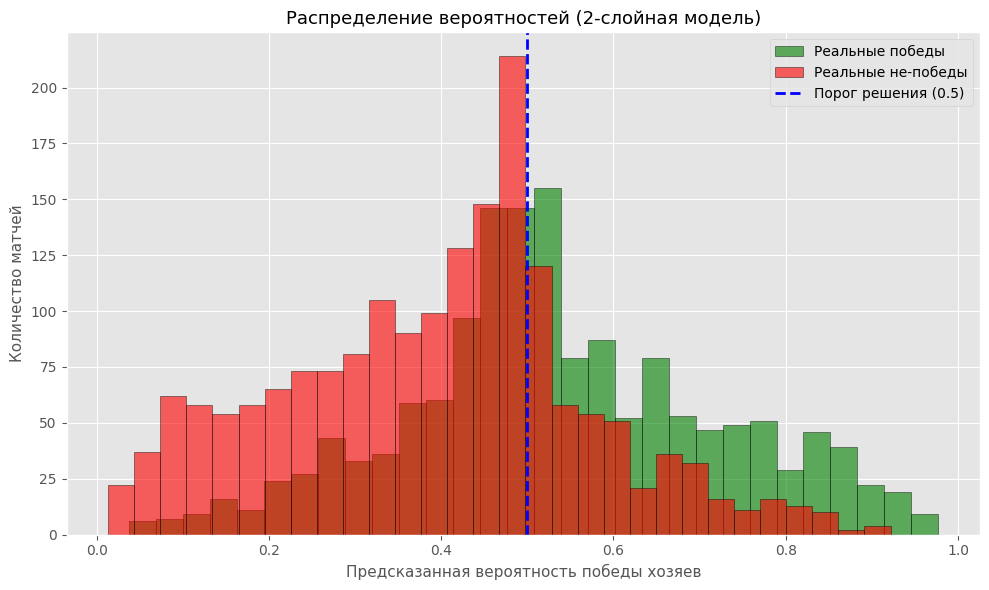

Сохранено: /content/drive/MyDrive/football_ml_project/plots/probability_dist_2layer.png

BASELINE
1. Случайное угадывание:     0.5013
2. Всегда 'не победа':       0.5411
3. Всегда 'победа':          0.4589
4. Логистическая регрессия:  0.6621 (AUC = 0.7147)

Наша MLP (2 слоя):           0.6627 (AUC = 0.7142)

Результаты сохранены: /content/drive/MyDrive/football_ml_project/results_2layer.json

ИТОГОВАЯ СВОДКА ЭТАПА 5.3
Accuracy:  0.6627
Precision: 0.6584
Recall:    0.5508
F1-score:  0.5998
ROC-AUC:   0.7142

Улучшение над baseline 'всегда не победа': +12.16%
Улучшение над логистической регрессией: +0.06%


In [19]:
try:
    train_loader, val_loader, test_loader
    X_train_scaled, X_test_scaled, y_train, y_test
    print("DataLoader'ы и данные уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: данные не найдены. Выполните Этапы 1-4 заново.")
    raise

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression


# ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
model_path = f'{PROJECT_PATH}/best_model.pth'
model = FootballMLP(input_size=9, dropout=0.3).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"Модель загружена: {model_path}")

# ПРЕДСКАЗАНИЯ НА TEST
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).squeeze()
        all_probs.extend(y_pred.cpu().numpy())
        all_targets.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
all_preds = (all_probs > 0.5).astype(int)

print(f"Предсказания получены: {len(all_preds)} матчей")
print(f"Средняя вероятность: {all_probs.mean():.4f}")

# МЕТРИКИ
accuracy = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)
roc_auc = roc_auc_score(all_targets, all_probs)

print("\n" + "="*60)
print("МЕТРИКИ НА TEST")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(all_targets, all_preds,
                            target_names=['Не победа', 'Победа']))

# МАТРИЦА ОШИБОК
cm = confusion_matrix(all_targets, all_preds)
print(f"\nМатрица ошибок:\n{cm}")

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не победа', 'Победа'],
            yticklabels=['Не победа', 'Победа'])
plt.title('Матрица ошибок (2-слойная модель)', fontsize=13)
plt.xlabel('Предсказание', fontsize=11)
plt.ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/confusion_matrix_2layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/confusion_matrix_2layer.png")

# ROC-КРИВАЯ
fpr, tpr, _ = roc_curve(all_targets, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MLP 2 слоя (AUC = {roc_auc:.3f})',
         linewidth=2, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-кривая (2-слойная модель)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/roc_curve_2layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/roc_curve_2layer.png")

# РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ
plt.figure(figsize=(10, 6))
plt.hist(all_probs[all_targets == 1], bins=30, alpha=0.6,
         label='Реальные победы', color='green', edgecolor='black')
plt.hist(all_probs[all_targets == 0], bins=30, alpha=0.6,
         label='Реальные не-победы', color='red', edgecolor='black')
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2,
            label='Порог решения (0.5)')
plt.xlabel('Предсказанная вероятность победы хозяев', fontsize=11)
plt.ylabel('Количество матчей', fontsize=11)
plt.title('Распределение вероятностей (2-слойная модель)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/probability_dist_2layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/probability_dist_2layer.png")

# BASELINE
print("\n" + "="*60)
print("BASELINE")
print("="*60)

np.random.seed(42)
random_preds = np.random.randint(0, 2, size=len(all_targets))
acc_random = accuracy_score(all_targets, random_preds)
print(f"1. Случайное угадывание:     {acc_random:.4f}")

always_zero = np.zeros(len(all_targets), dtype=int)
acc_zero = accuracy_score(all_targets, always_zero)
print(f"2. Всегда 'не победа':       {acc_zero:.4f}")

always_one = np.ones(len(all_targets), dtype=int)
acc_one = accuracy_score(all_targets, always_one)
print(f"3. Всегда 'победа':          {acc_one:.4f}")

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1])
print(f"4. Логистическая регрессия:  {acc_log:.4f} (AUC = {roc_auc_log:.4f})")

print(f"\nНаша MLP (2 слоя):           {accuracy:.4f} (AUC = {roc_auc:.4f})")

# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В JSON
results = {
    'model': 'MLP 2 layers (9-128-64-1)',
    'test_accuracy': float(accuracy),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'test_roc_auc': float(roc_auc),
    'baseline_random': float(acc_random),
    'baseline_always_zero': float(acc_zero),
    'baseline_always_one': float(acc_one),
    'baseline_logistic_regression': float(acc_log),
    'baseline_logistic_regression_auc': float(roc_auc_log)
}

with open(f'{PROJECT_PATH}/results_2layer.json', 'w') as f:
    json.dump(results, f, indent=4)
print(f"\nРезультаты сохранены: {PROJECT_PATH}/results_2layer.json")

# ИТОГОВАЯ СВОДКА
print("\n" + "="*60)
print("ИТОГОВАЯ СВОДКА ЭТАПА 5.3")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"\nУлучшение над baseline 'всегда не победа': "
      f"+{(accuracy - acc_zero)*100:.2f}%")
print(f"Улучшение над логистической регрессией: "
      f"+{(accuracy - acc_log)*100:.2f}%")

Построение 3-слойной модели

DataLoader'ы уже в памяти. Продолжаем.

Всего параметров в 3-слойной модели: 12097

Всего комбинаций: 12
  № |       lr |  weight_decay |  Val Loss |  Val Acc |  Epoch |   Time
---------------------------------------------------------------------------
  1 |   0.0001 |       0.0e+00 |    0.6165 |   0.6372 |     15 |  25.4s
  2 |   0.0001 |       1.0e-05 |    0.6165 |   0.6381 |     15 |  25.4s
  3 |   0.0001 |       1.0e-04 |    0.6164 |   0.6384 |     15 |  25.9s
  4 |   0.0001 |       1.0e-03 |    0.6166 |   0.6423 |      8 |  18.6s
  5 |   0.0010 |       0.0e+00 |    0.6152 |   0.6420 |      9 |  18.9s
  6 |   0.0010 |       1.0e-05 |    0.6153 |   0.6366 |      4 |  14.9s
  7 |   0.0010 |       1.0e-04 |    0.6154 |   0.6420 |      9 |  19.0s
  8 |   0.0010 |       1.0e-03 |    0.6151 |   0.6366 |      4 |  14.3s
  9 |   0.0100 |       0.0e+00 |    0.6149 |   0.6423 |      9 |  20.1s
 10 |   0.0100 |       1.0e-05 |    0.6154 |   0.6363 |      4 |  21.5s
 11 |   0.0100 |       1.0e

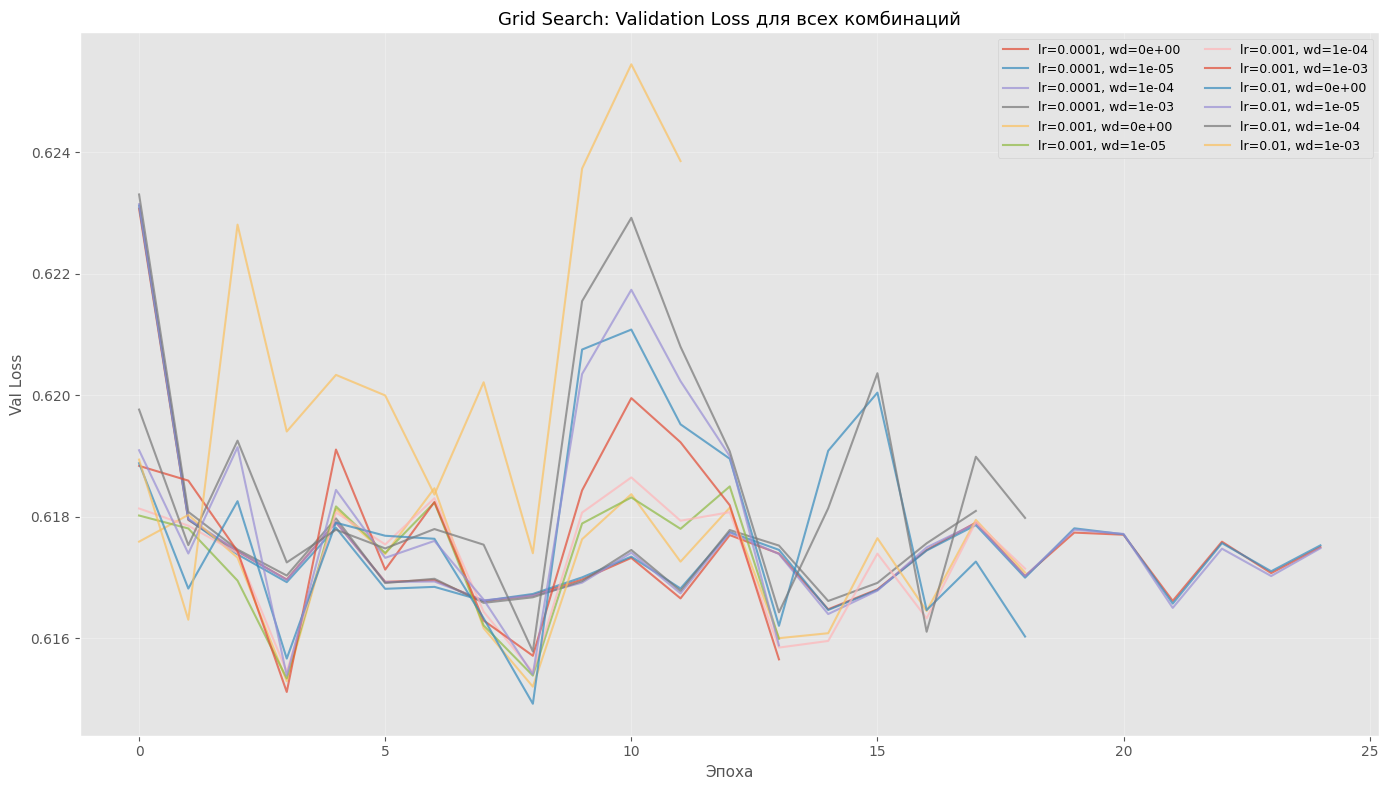

График сохранен: /content/drive/MyDrive/football_ml_project/plots/grid_search_3layer.png
Результаты Grid Search сохранены: /content/drive/MyDrive/football_ml_project/grid_search_3layer.json

ИТОГИ ОБУЧЕНИЯ
Проверено комбинаций: 12
Лучшая комбинация: lr=0.01, weight_decay=0
  Best Val Loss: 0.6149
  Best Val Acc:  0.6423
  Best Epoch:    9

Сохраненные файлы:
  - /content/drive/MyDrive/football_ml_project/best_model_3layer.pth
  - /content/drive/MyDrive/football_ml_project/grid_search_3layer.json
  - /content/drive/MyDrive/football_ml_project/plots/grid_search_3layer.png


In [21]:
try:
    train_loader, val_loader, test_loader
    print("DataLoader'ы уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: DataLoader'ы не найдены. Выполните Этап 4 заново.")
    raise

import itertools
import torch.nn as nn
import torch.optim as optim

# ОПРЕДЕЛЕНИЕ 3-СЛОЙНОЙ МОДЕЛИ


class FootballMLP3(nn.Module):
    def __init__(self, input_size=9, dropout=0.3):
        super(FootballMLP3, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        x = self.sigmoid(self.fc4(x))
        return x

model_test = FootballMLP3()
total_params = sum(p.numel() for p in model_test.parameters())
print(f"\nВсего параметров в 3-слойной модели: {total_params}")

# ФУНКЦИЯ ОБУЧЕНИЯ

def train_model_3layer(lr, weight_decay, max_epochs=100, patience=10):
    torch.manual_seed(42)
    model = FootballMLP3(input_size=9, dropout=0.3).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        # TRAIN
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            train_correct += ((y_pred > 0.5).float() == y_batch).sum().item()
            train_total += len(y_batch)
        train_loss /= train_total
        train_acc = train_correct / train_total

        # VALIDATION
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch).squeeze()
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += ((y_pred > 0.5).float() == y_batch).sum().item()
                val_total += len(y_batch)
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    return history, best_val_loss, best_val_acc, best_epoch, epoch + 1, best_model_state

# GRID SEARCH

learning_rates = [0.0001, 0.001, 0.01]
weight_decays = [0, 1e-5, 1e-4, 1e-3]

combinations = list(itertools.product(learning_rates, weight_decays))
print(f"\nВсего комбинаций: {len(combinations)}")
print(f"{'№':>3} | {'lr':>8} | {'weight_decay':>13} | {'Val Loss':>9} | {'Val Acc':>8} | {'Epoch':>6} | {'Time':>6}")
print("-" * 75)

grid_results = []
start_total = time.time()

for i, (lr, wd) in enumerate(combinations, 1):
    start = time.time()
    history, best_val_loss, best_val_acc, best_epoch, stopped, best_state = train_model_3layer(
        lr=lr, weight_decay=wd, max_epochs=100, patience=10
    )
    elapsed = time.time() - start

    grid_results.append({
        'lr': lr,
        'weight_decay': wd,
        'history': history,
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'stopped_epoch': stopped,
        'best_model_state': best_state,
        'time': elapsed
    })

    print(f"{i:>3} | {lr:>8.4f} | {wd:>13.1e} | {best_val_loss:>9.4f} | "
          f"{best_val_acc:>8.4f} | {best_epoch:>6d} | {elapsed:>5.1f}s")

total_time = time.time() - start_total
print(f"\nОбщее время Grid Search: {total_time:.1f} сек")

# ВЫБОР ЛУЧШЕЙ КОМБИНАЦИИ

best_result = min(grid_results, key=lambda x: x['best_val_loss'])
best_lr = best_result['lr']
best_wd = best_result['weight_decay']

print("\n" + "="*60)
print("ЛУЧШАЯ КОМБИНАЦИЯ")
print("="*60)
print(f"lr:           {best_lr}")
print(f"weight_decay: {best_wd}")
print(f"Best Val Loss: {best_result['best_val_loss']:.4f}")
print(f"Best Val Acc:  {best_result['best_val_acc']:.4f}")
print(f"Best Epoch:    {best_result['best_epoch']}")

# СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ

best_model = FootballMLP3(input_size=9, dropout=0.3).to(device)
best_model.load_state_dict(best_result['best_model_state'])
model_path = f'{PROJECT_PATH}/best_model_3layer.pth'
torch.save(best_model.state_dict(), model_path)
print(f"\nЛучшая 3-слойная модель сохранена: {model_path}")

# ГРАФИК СРАВНЕНИЯ

plt.figure(figsize=(14, 8))
for i, r in enumerate(grid_results):
    label = f"lr={r['lr']}, wd={r['weight_decay']:.0e}"
    plt.plot(r['history']['val_loss'], label=label, linewidth=1.5, alpha=0.7)
plt.title('Grid Search: Validation Loss для всех комбинаций', fontsize=13)
plt.xlabel('Эпоха', fontsize=11)
plt.ylabel('Val Loss', fontsize=11)
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/grid_search_3layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"График сохранен: {PLOTS_PATH}/grid_search_3layer.png")

# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В JSON

grid_results_json = []
for r in grid_results:
    grid_results_json.append({
        'lr': float(r['lr']),
        'weight_decay': float(r['weight_decay']),
        'best_val_loss': float(r['best_val_loss']),
        'best_val_acc': float(r['best_val_acc']),
        'best_epoch': int(r['best_epoch']),
        'stopped_epoch': int(r['stopped_epoch']),
        'time_seconds': float(r['time'])
    })

output = {
    'total_combinations': len(combinations),
    'total_time_seconds': float(total_time),
    'best_lr': float(best_lr),
    'best_weight_decay': float(best_wd),
    'best_val_loss': float(best_result['best_val_loss']),
    'best_val_acc': float(best_result['best_val_acc']),
    'best_epoch': int(best_result['best_epoch']),
    'all_results': grid_results_json
}

with open(f'{PROJECT_PATH}/grid_search_3layer.json', 'w') as f:
    json.dump(output, f, indent=4)
print(f"Результаты Grid Search сохранены: {PROJECT_PATH}/grid_search_3layer.json")

# ============================================================
# ИТОГИ ОБУЧЕНИЯ
# ============================================================

print("\n" + "="*60)
print("ИТОГИ ОБУЧЕНИЯ")
print("="*60)
print(f"Проверено комбинаций: {len(combinations)}")
print(f"Лучшая комбинация: lr={best_lr}, weight_decay={best_wd}")
print(f"  Best Val Loss: {best_result['best_val_loss']:.4f}")
print(f"  Best Val Acc:  {best_result['best_val_acc']:.4f}")
print(f"  Best Epoch:    {best_result['best_epoch']}")
print(f"\nСохраненные файлы:")
print(f"  - {PROJECT_PATH}/best_model_3layer.pth")
print(f"  - {PROJECT_PATH}/grid_search_3layer.json")
print(f"  - {PLOTS_PATH}/grid_search_3layer.png")

Оценка 3 слойной модели на test

DataLoader'ы и данные уже в памяти. Продолжаем.
Модель загружена: /content/drive/MyDrive/football_ml_project/best_model_3layer.pth
Предсказания получены: 3347 матчей
Средняя вероятность: 0.4626

МЕТРИКИ 3-СЛОЙНОЙ МОДЕЛИ НА TEST
Accuracy:  0.6636
Precision: 0.6801
Recall:    0.5039
F1-score:  0.5789
ROC-AUC:   0.7145

Classification Report:
              precision    recall  f1-score   support

   Не победа       0.66      0.80      0.72      1811
      Победа       0.68      0.50      0.58      1536

    accuracy                           0.66      3347
   macro avg       0.67      0.65      0.65      3347
weighted avg       0.67      0.66      0.66      3347


Матрица ошибок:
[[1447  364]
 [ 762  774]]


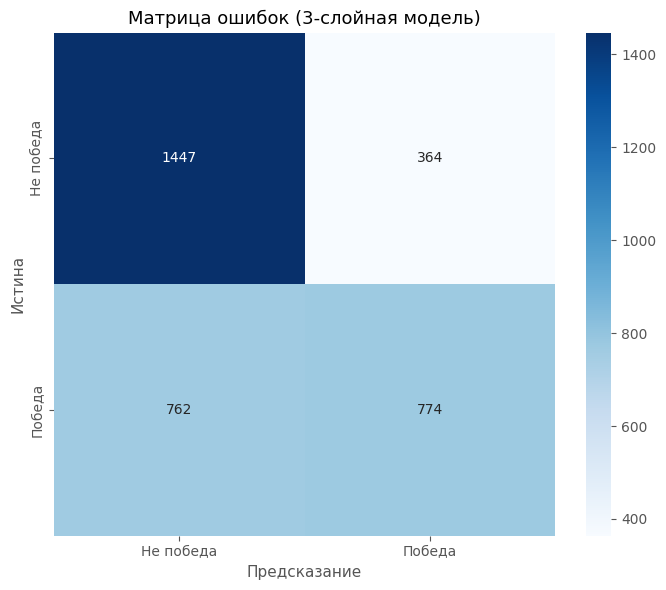

Сохранено: /content/drive/MyDrive/football_ml_project/plots/confusion_matrix_3layer.png


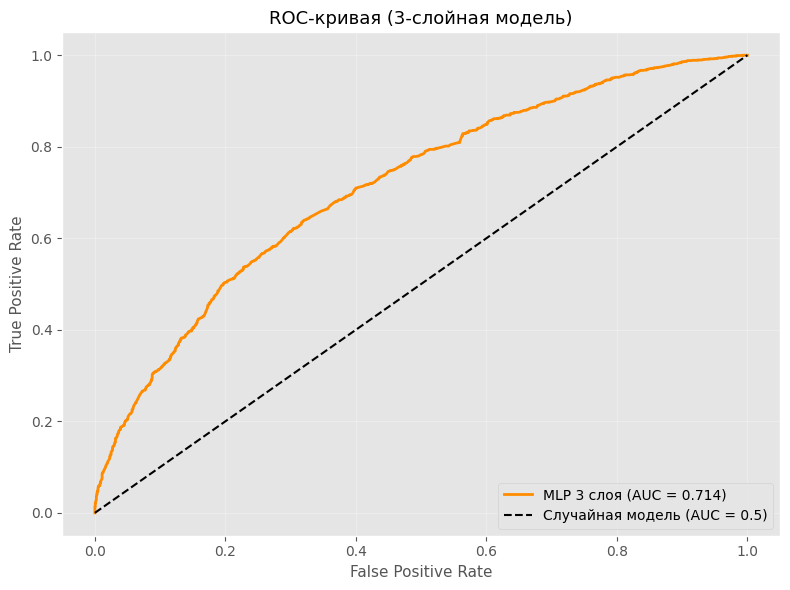

Сохранено: /content/drive/MyDrive/football_ml_project/plots/roc_curve_3layer.png


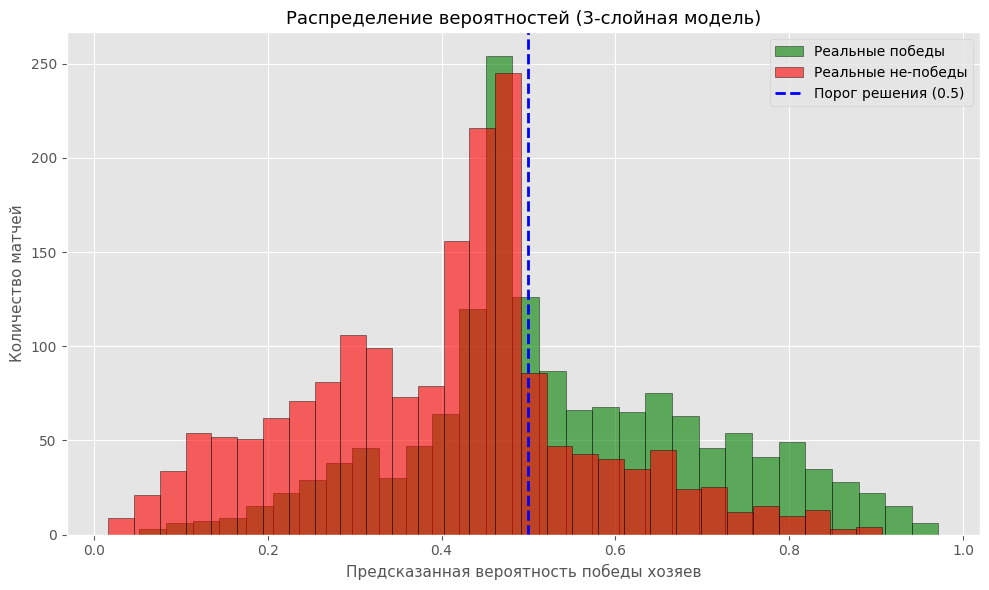

Сохранено: /content/drive/MyDrive/football_ml_project/plots/probability_dist_3layer.png

СРАВНЕНИЕ 2-СЛОЙНОЙ И 3-СЛОЙНОЙ МОДЕЛЕЙ

Метрика              |     2 слоя |     3 слоя |    Разница
------------------------------------------------------------
Accuracy             |     0.6627 |     0.6636 | +   0.0009
Precision            |     0.6584 |     0.6801 | +   0.0218
Recall               |     0.5508 |     0.5039 |   -0.0469
F1-score             |     0.5998 |     0.5789 |   -0.0209
ROC-AUC              |     0.7142 |     0.7145 | +   0.0003

BASELINE
1. Случайное угадывание:     0.5013
2. Всегда 'не победа':       0.5411
3. Всегда 'победа':          0.4589
4. Логистическая регрессия:  0.6621 (AUC = 0.7147)

2-слойная MLP:               0.6627 (AUC = 0.7142)
3-слойная MLP:               0.6636 (AUC = 0.7145)

Результаты сохранены: /content/drive/MyDrive/football_ml_project/results_3layer.json

ИТОГОВАЯ СВОДКА
3-слойная модель:
  Accuracy:  0.6636
  Precision: 0.6801
  Recall:    0.503

In [23]:
try:
    train_loader, val_loader, test_loader
    X_train_scaled, X_test_scaled, y_train, y_test
    print("DataLoader'ы и данные уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: данные не найдены. Выполните Этапы 1-4 заново.")
    raise

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression

# ЗАГРУЗКА ЛУЧШЕЙ 3-СЛОЙНОЙ МОДЕЛИ
model_path = f'{PROJECT_PATH}/best_model_3layer.pth'
model3 = FootballMLP3(input_size=9, dropout=0.3).to(device)
model3.load_state_dict(torch.load(model_path, map_location=device))
model3.eval()
print(f"Модель загружена: {model_path}")

# ПРЕДСКАЗАНИЯ НА TEST
all_probs_3 = []
all_targets_3 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model3(X_batch).squeeze()
        all_probs_3.extend(y_pred.cpu().numpy())
        all_targets_3.extend(y_batch.numpy())

all_probs_3 = np.array(all_probs_3)
all_targets_3 = np.array(all_targets_3)
all_preds_3 = (all_probs_3 > 0.5).astype(int)

print(f"Предсказания получены: {len(all_preds_3)} матчей")
print(f"Средняя вероятность: {all_probs_3.mean():.4f}")

# МЕТРИКИ
accuracy_3 = accuracy_score(all_targets_3, all_preds_3)
precision_3 = precision_score(all_targets_3, all_preds_3)
recall_3 = recall_score(all_targets_3, all_preds_3)
f1_3 = f1_score(all_targets_3, all_preds_3)
roc_auc_3 = roc_auc_score(all_targets_3, all_probs_3)

print("\n" + "="*60)
print("МЕТРИКИ 3-СЛОЙНОЙ МОДЕЛИ НА TEST")
print("="*60)
print(f"Accuracy:  {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall:    {recall_3:.4f}")
print(f"F1-score:  {f1_3:.4f}")
print(f"ROC-AUC:   {roc_auc_3:.4f}")

print("\nClassification Report:")
print(classification_report(all_targets_3, all_preds_3,
                            target_names=['Не победа', 'Победа']))

# МАТРИЦА ОШИБОК
cm_3 = confusion_matrix(all_targets_3, all_preds_3)
print(f"\nМатрица ошибок:\n{cm_3}")

plt.figure(figsize=(7, 6))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не победа', 'Победа'],
            yticklabels=['Не победа', 'Победа'])
plt.title('Матрица ошибок (3-слойная модель)', fontsize=13)
plt.xlabel('Предсказание', fontsize=11)
plt.ylabel('Истина', fontsize=11)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/confusion_matrix_3layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/confusion_matrix_3layer.png")

# ROC-КРИВАЯ
fpr_3, tpr_3, _ = roc_curve(all_targets_3, all_probs_3)

plt.figure(figsize=(8, 6))
plt.plot(fpr_3, tpr_3, label=f'MLP 3 слоя (AUC = {roc_auc_3:.3f})',
         linewidth=2, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-кривая (3-слойная модель)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/roc_curve_3layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/roc_curve_3layer.png")

# РАСПРЕДЕЛЕНИЕ ВЕРОЯТНОСТЕЙ
plt.figure(figsize=(10, 6))
plt.hist(all_probs_3[all_targets_3 == 1], bins=30, alpha=0.6,
         label='Реальные победы', color='green', edgecolor='black')
plt.hist(all_probs_3[all_targets_3 == 0], bins=30, alpha=0.6,
         label='Реальные не-победы', color='red', edgecolor='black')
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2,
            label='Порог решения (0.5)')
plt.xlabel('Предсказанная вероятность победы хозяев', fontsize=11)
plt.ylabel('Количество матчей', fontsize=11)
plt.title('Распределение вероятностей (3-слойная модель)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/probability_dist_3layer.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранено: {PLOTS_PATH}/probability_dist_3layer.png")

# СРАВНЕНИЕ С 2-СЛОЙНОЙ МОДЕЛЬЮ
print("\n" + "="*60)
print("СРАВНЕНИЕ 2-СЛОЙНОЙ И 3-СЛОЙНОЙ МОДЕЛЕЙ")
print("="*60)

# Загружаем результаты 2-слойной модели
try:
    with open(f'{PROJECT_PATH}/results_2layer.json', 'r') as f:
        results_2 = json.load(f)
    has_2layer = True
except FileNotFoundError:
    print("Результаты 2-слойной модели не найдены. Пропускаем сравнение.")
    has_2layer = False

if has_2layer:
    print(f"\n{'Метрика':<20} | {'2 слоя':>10} | {'3 слоя':>10} | {'Разница':>10}")
    print("-" * 60)

    metrics = [
        ('Accuracy', results_2['test_accuracy'], accuracy_3),
        ('Precision', results_2['test_precision'], precision_3),
        ('Recall', results_2['test_recall'], recall_3),
        ('F1-score', results_2['test_f1'], f1_3),
        ('ROC-AUC', results_2['test_roc_auc'], roc_auc_3),
    ]

    for name, v2, v3 in metrics:
        diff = v3 - v2
        sign = '+' if diff >= 0 else ''
        print(f"{name:<20} | {v2:>10.4f} | {v3:>10.4f} | {sign}{diff:>9.4f}")

# BASELINE
print("\n" + "="*60)
print("BASELINE")
print("="*60)

np.random.seed(42)
random_preds = np.random.randint(0, 2, size=len(all_targets_3))
acc_random = accuracy_score(all_targets_3, random_preds)
print(f"1. Случайное угадывание:     {acc_random:.4f}")

always_zero = np.zeros(len(all_targets_3), dtype=int)
acc_zero = accuracy_score(all_targets_3, always_zero)
print(f"2. Всегда 'не победа':       {acc_zero:.4f}")

always_one = np.ones(len(all_targets_3), dtype=int)
acc_one = accuracy_score(all_targets_3, always_one)
print(f"3. Всегда 'победа':          {acc_one:.4f}")

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1])
print(f"4. Логистическая регрессия:  {acc_log:.4f} (AUC = {roc_auc_log:.4f})")

print(f"\n2-слойная MLP:               {results_2['test_accuracy']:.4f} (AUC = {results_2['test_roc_auc']:.4f})" if has_2layer else "")
print(f"3-слойная MLP:               {accuracy_3:.4f} (AUC = {roc_auc_3:.4f})")

# 9. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В JSON
results_3 = {
    'model': 'MLP 3 layers (9-128-64-32-1)',
    'test_accuracy': float(accuracy_3),
    'test_precision': float(precision_3),
    'test_recall': float(recall_3),
    'test_f1': float(f1_3),
    'test_roc_auc': float(roc_auc_3),
    'best_hyperparams': {
        'lr': 0.01,
        'weight_decay': 0.0
    },
    'baseline_random': float(acc_random),
    'baseline_always_zero': float(acc_zero),
    'baseline_always_one': float(acc_one),
    'baseline_logistic_regression': float(acc_log),
    'baseline_logistic_regression_auc': float(roc_auc_log)
}

if has_2layer:
    results_3['comparison_with_2layer'] = {
        '2layer_accuracy': results_2['test_accuracy'],
        '2layer_roc_auc': results_2['test_roc_auc'],
        'accuracy_diff': float(accuracy_3 - results_2['test_accuracy']),
        'roc_auc_diff': float(roc_auc_3 - results_2['test_roc_auc'])
    }

with open(f'{PROJECT_PATH}/results_3layer.json', 'w') as f:
    json.dump(results_3, f, indent=4)
print(f"\nРезультаты сохранены: {PROJECT_PATH}/results_3layer.json")

# ИТОГОВАЯ СВОДКА
print("\n" + "="*60)
print("ИТОГОВАЯ СВОДКА")
print("="*60)
print(f"3-слойная модель:")
print(f"  Accuracy:  {accuracy_3:.4f}")
print(f"  Precision: {precision_3:.4f}")
print(f"  Recall:    {recall_3:.4f}")
print(f"  F1-score:  {f1_3:.4f}")
print(f"  ROC-AUC:   {roc_auc_3:.4f}")

if has_2layer:
    print(f"\nСравнение с 2-слойной:")
    print(f"  Accuracy:  {results_2['test_accuracy']:.4f} → {accuracy_3:.4f} "
          f"({'+' if accuracy_3 >= results_2['test_accuracy'] else ''}"
          f"{(accuracy_3 - results_2['test_accuracy'])*100:.2f}%)")
    print(f"  ROC-AUC:   {results_2['test_roc_auc']:.4f} → {roc_auc_3:.4f} "
          f"({'+' if roc_auc_3 >= results_2['test_roc_auc'] else ''}"
          f"{(roc_auc_3 - results_2['test_roc_auc'])*100:.2f}%)")

print(f"\nУлучшение над baseline 'всегда не победа': "
      f"+{(accuracy_3 - acc_zero)*100:.2f}%")
print(f"Улучшение над логистической регрессией: "
      f"+{(accuracy_3 - acc_log)*100:.2f}%")